# Handover Project: Statistical Analysis

This notebook performs statistical analysis on the aggregated metrics from the handover project experiments. It focuses on within-subjects comparisons across different report generation conditions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import os

# Settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

# Path to the aggregated metrics
CSV_PATH = "/media/kaleb/T7/handover_project/participant_data/analysis/metrics_output/aggregated_metrics.csv"

if not os.path.exists(CSV_PATH):
    print(f"Warning: {CSV_PATH} not found. Please check the path.")

## 1. Load and Prepare Data

In [2]:
df_all = pd.read_csv(CSV_PATH)
import os

# get derived metric (communicative compression)
df_all["communicative_compression"] = df_all["iac_cost_saved"].div(df_all["token_count"])

# rename conditions
condition_mapping = {
    "user_report": "user-only",
    "full_realization": "FR",
    "task_aware": "TA",
    "task_aware_raw_ablation": "end2end",
    "no_report_task_aware": "TA -user"
}

df_all.replace(condition_mapping, inplace=True)

# Ensure consistent conditions
conditions = list(condition_mapping.values())
df_all = df_all[df_all["condition"].isin(conditions)]

print(f"Loaded raw metrics with unique models: {df_all['model'].unique()}")


Loaded raw metrics with unique models: <StringArray>
['claude', 'gemini', 'gpt', 'gpt4-1-mini', 'gpt5-6-terra', 'human']
Length: 6, dtype: str


In [3]:
# plt.figure(figsize=(12, 6))
# sns.barplot(data=df, x='participant_id', y='iac_combined_cost', hue='condition')
# plt.title('IAC Combined Cost Across Conditions Within Each Participant')
# plt.ylabel('IAC Combined Cost (in steps)')
# plt.xlabel('Participant ID')
# plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

In [4]:
# Sourced alpha from CostConfig in src/pipelines/evaluation/costs.py
import sys
import os
if os.path.abspath("..") not in sys.path:
    sys.path.append(os.path.abspath(".."))
from src.pipelines.evaluation.costs import CostConfig

cost_config = CostConfig()
alpha = cost_config.misinformation_multiplier

# Calculate percentage shares of omission and misinformation costs as contributors to combined cost
df_all["omission_share_pct"] = (df_all["iac_omission_cost"] / df_all["iac_combined_cost"] * 100).fillna(0)
df_all["misinformation_share_pct"] = ((alpha * df_all["iac_misinformation_cost"]) / df_all["iac_combined_cost"] * 100).fillna(0)

conditions_order = ["user-only", "FR", "TA", "end2end", "TA -user"]


In [5]:
def create_summary_table(model_df):
    iac_summary_data = []
    for cond in conditions_order:
        cond_df = model_df[model_df["condition"] == cond]
        
        # Combined cost stats
        med_combined = cond_df["iac_combined_cost"].median()
        min_combined = cond_df["iac_combined_cost"].min()
        max_combined = cond_df["iac_combined_cost"].max()
        
        # Omission share stats
        med_omission = cond_df["omission_share_pct"].median()
        min_omission = cond_df["omission_share_pct"].min()
        max_omission = cond_df["omission_share_pct"].max()
        
        # Misinformation share stats
        med_misinfo = cond_df["misinformation_share_pct"].median()
        min_misinfo = cond_df["misinformation_share_pct"].min()
        max_misinfo = cond_df["misinformation_share_pct"].max()
        
        iac_summary_data.append({
            "Condition": cond,
            "Median Combined Cost": round(med_combined, 2),
            "Range Combined Cost": f"[{min_combined:.2f}, {max_combined:.2f}]",
            "Median Omission Share (%)": f"{med_omission:.1f}%",
            "Range Omission Share (%)": f"[{min_omission:.1f}%, {max_omission:.1f}%]",
            "Median Misinformation Share (%)": f"{med_misinfo:.1f}%",
            "Range Misinformation Share (%)": f"[{min_misinfo:.1f}%, {max_misinfo:.1f}%]"
        })

    df_iac_summary = pd.DataFrame(iac_summary_data)
    print(f"Misinformation multiplier (alpha) used in calculations: {alpha}")
    print("\nInformation Access Cost (IAC) Summary Table:")
    display(df_iac_summary)

## 2. Statistical Helper Functions

We use non-parametric tests as the sample size is small and we cannot assume normality.
- **Wilcoxon Signed-Rank Test**: For 2-group within-subjects comparisons.
- **Friedman Test**: For 3+ group within-subjects comparisons.
- **Kendall's W**: Effect size for Friedman test.
- **Rank-Biserial Correlation (r)**: Effect size for Wilcoxon test.

In [6]:
def calculate_kendall_w(friedman_stat, n, k):
    """Calculates Kendall's W for Friedman test."""
    return friedman_stat / (n * (k - 1))

def calculate_rank_biserial(wilcoxon_stat, n):
    """Calculates Rank-Biserial Correlation (r) for Wilcoxon test."""
    # r = 1 - (2 * W / (n * (n + 1)))
    # Or more robustly via Z: r = Z / sqrt(N)
    # Scipy doesn't return Z directly, but we can approximate or use the formula below
    # Using a simpler r = Z / sqrt(n) approach if we had Z, 
    # but for Wilcoxon, common r = 1 - (4 * W / (n * (n + 1)))
    # Here we'll use a simplified version: r = 1 - (2 * W / total_rank_sum)
    total_ranks = n * (n + 1) / 2
    return 1 - (2 * wilcoxon_stat / total_ranks)

def annotate_stats(ax, p_value, x1, x2, y, h):
    """Adds significance markers to a plot."""
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        sig = "n.s."
    
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, c='k')
    ax.text((x1+x2)*.5, y+h, sig, ha='center', va='bottom', color='k', fontsize=12)



## 3. Descriptives: Content categorization of user-onlys


In [7]:
CATEGORY_CSV = "/media/kaleb/T7/handover_project/participant_data/analysis/content_categorization/aggregated_content_categorization.csv"

content_df = pd.read_csv(CATEGORY_CSV)
content_df = content_df.set_index("participant_id")
content_df.index = content_df.index.astype(str)

content_props = content_df.copy()
content_props["total tokens"] = content_props.sum(axis=1)
content_props = content_props.drop(
                    columns=["total tokens"]
                ).div(
                    content_props["total tokens"], axis=0
                )

content_props


,state,knowledge,ambiguous,meta
participant_id,,,,
501,0.326241,0.609929,0.063830,0.000000
502,0.500000,0.161765,0.338235,0.000000
503,0.770492,0.229508,0.000000,0.000000
504,0.771739,0.000000,0.000000,0.228261
505,0.382609,0.617391,0.000000,0.000000
506,0.780645,0.219355,0.000000,0.000000
507,0.418367,0.500000,0.000000,0.081633
508,0.480447,0.519553,0.000000,0.000000
509,0.494774,0.351916,0.128920,0.024390


In [8]:
# Calculate descriptive statistics (mean, median, range, std) of the percent of each content type relative to total token count
content_pcts = content_props * 100
descriptive_stats = pd.DataFrame({
    'mean': content_pcts.mean(),
    'median': content_pcts.median(),
    'minimum': content_pcts.min(),
    'maximum': content_pcts.max(),
    'std': content_pcts.std()
}).T
descriptive_stats

,state,knowledge,ambiguous,meta
mean,54.889272,35.324774,6.563340,3.222614
median,50.000000,35.191638,0.000000,0.000000
minimum,17.989418,0.000000,0.000000,0.000000
maximum,78.064516,66.137566,33.823529,22.826087
std,19.494296,21.491589,11.036867,6.647533


### Summary of Content Category Descriptives (Percentages)

The descriptive statistics for each content category (expressed as percentages of the total token count) reveal the following patterns across participant reports:
- **State** tokens represent the majority of the content, with a mean of **54.89%** (median = 50.00%, SD = 19.49%).
- **Knowledge** tokens are the second most common type, comprising a mean of **35.32%** (median = 35.19%, SD = 21.49%).
- **Ambiguous** (mean = 6.56%, median = 0.00%, SD = 11.04%) and **Meta** (mean = 3.22%, median = 0.00%, SD = 6.65%) tokens are much less frequent and are absent in many participant reports.

We also note substantial individual variation across participants, particularly in the proportions of state (range = 60.08%) and knowledge (range = 66.14%) tokens.

<Axes: title={'center': 'Content makeup in user-onlys by category'}, xlabel='content label', ylabel='proportion of tokens in report'>

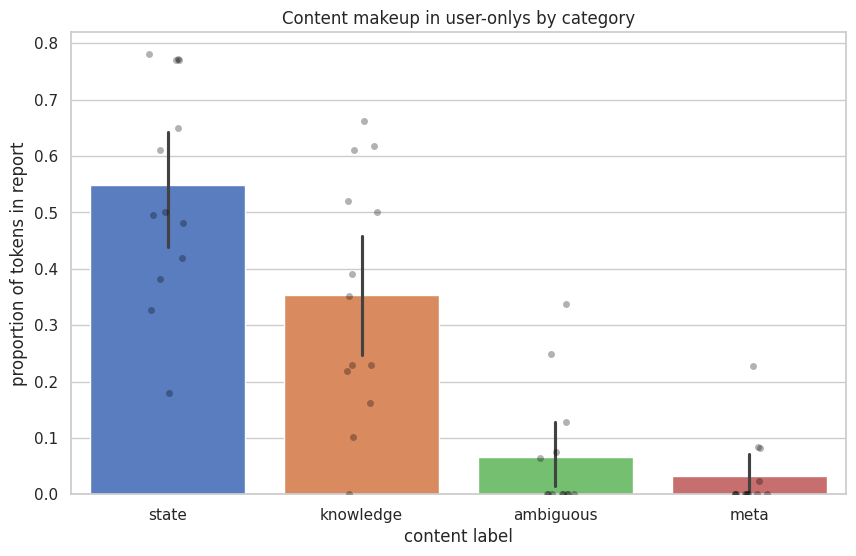

In [9]:
ax = sns.barplot(data=content_props)
ax.set_xlabel("content label")
ax.set_ylabel("proportion of tokens in report")
ax.set_title("Content makeup in user-onlys by category")
sns.stripplot(data=content_props, ax=ax, color='black', alpha=0.3)

Text(0.5, 1.0, 'Content makeup in user-onlys by user')

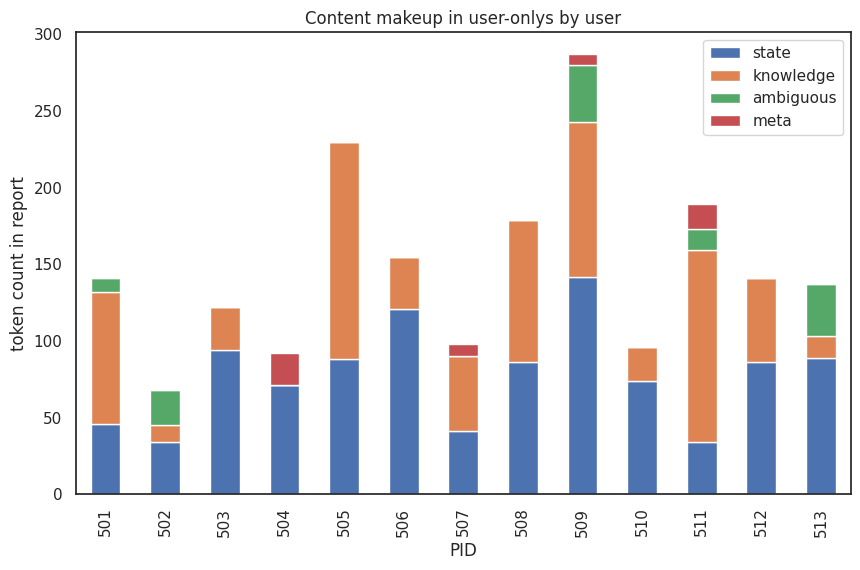

In [10]:
sns.set(style="white")
ax = content_df.plot(kind="bar", stacked=True)
ax.set_xlabel("PID")
ax.set_ylabel("token count in report")
ax.set_title("Content makeup in user-onlys by user")

## 4. Analysis for Model: GPT-4.1-Mini


In [11]:
selected_model = "gpt4-1-mini"
df = df_all[df_all["model"] == selected_model].copy()
df_wide = df.pivot(index='participant_id', columns='condition')
df_wide.index = df_wide.index.astype(str)
print(f"Loaded metrics for {len(df_wide)} participants for model: {selected_model}")


Loaded metrics for 13 participants for model: gpt4-1-mini


### 4.1 Summary Statistics


In [12]:
create_summary_table(df)


Misinformation multiplier (alpha) used in calculations: 3.0

Information Access Cost (IAC) Summary Table:


,Condition,Median Combined Cost,Range Combined Cost,Median Omission Share (%),Range Omission Share (%),Median Misinformation Share (%),Range Misinformation Share (%)
0,user-only,773.5,"[222.50, 1745.74]",84.7%,"[38.2%, 100.0%]",15.3%,"[0.0%, 61.8%]"
1,FR,233.2,"[101.50, 754.41]",100.0%,"[36.8%, 100.0%]",0.0%,"[0.0%, 63.2%]"
2,TA,241.2,"[101.50, 568.90]",100.0%,"[36.8%, 100.0%]",0.0%,"[0.0%, 63.2%]"
3,end2end,626.5,"[226.20, 1206.50]",35.0%,"[16.8%, 100.0%]",65.0%,"[0.0%, 83.2%]"
4,TA -user,233.0,"[135.00, 384.40]",100.0%,"[100.0%, 100.0%]",0.0%,"[0.0%, 0.0%]"


### 4.2 Analysis: Precision, Recall, and F1


In [13]:
metrics_pr = ['precision', 'recall', 'f1']
results_pr = []
posthoc_pr_results = []

pairs = [
    ("user-only", "TA"),
    ("FR", "TA"),
    ("TA", "end2end"),
    ("TA", "TA -user")
]

for metric in metrics_pr:
    data = [df_wide[metric][c] for c in conditions]

    # Remove participants with any NaNs in these columns
    mask = ~(data[0].isna() | data[1].isna() | data[2].isna())
    data = [d[mask] for d in data]
    if len(data[0]) < 2:
        continue
        
    stat, p = stats.friedmanchisquare(*data)
    w = calculate_kendall_w(stat, len(data[0]), len(conditions))
    
    results_pr.append({
        'Metric': metric,
        'Friedman Stat': stat,
        'p-value': p,
        'Kendall\'s W': w
    })
    
    # Post-hoc if significant
    if p < 0.05:
        p_vals = []
        medians = []
        w_stats = []
        r_vals = []
        for p1, p2 in pairs:
            pair_mask = ~(df_wide[metric][p1].isna() | df_wide[metric][p2].isna())
            w_stat, pp = stats.wilcoxon(df_wide[metric][p1][pair_mask], df_wide[metric][p2][pair_mask])
            p_vals.append(pp)
            medians.append((df_wide[metric][p1][pair_mask].median(), df_wide[metric][p2][pair_mask].median()))
            w_stats.append(w_stat)
            r_val = calculate_rank_biserial(w_stat, pair_mask.sum())
            r_vals.append(r_val)
        
        # Holm correction
        _, p_adj, _, _ = multipletests(p_vals, method='holm')
        
        for i, pair in enumerate(pairs):
            posthoc_pr_results.append({
                'Metric': metric,
                'Comparison': f"{pair[0]} vs {pair[1]}",
                'Median 1': medians[i][0],
                'Median 2': medians[i][1],
                'Wilcoxon W': w_stats[i],
                'p-adj': p_adj[i],
                'Effect Size (r)': r_vals[i]
            })

results_pr_df = pd.DataFrame(results_pr)
posthoc_pr_df = pd.DataFrame(posthoc_pr_results)

print("Precision / Recall / F1 Statistical Results (Friedman Test):")
display(results_pr_df)
if not posthoc_pr_df.empty:
    print("\nPost-hoc Wilcoxon (Holm-corrected):")
    display(posthoc_pr_df)

Precision / Recall / F1 Statistical Results (Friedman Test):


,Metric,Friedman Stat,p-value,Kendall's W
0,precision,42.889796,1.090729e-08,0.824804
1,recall,48.314961,8.113472e-10,0.929134
2,f1,46.501931,1.936258e-09,0.894268



Post-hoc Wilcoxon (Holm-corrected):


,Metric,Comparison,Median 1,Median 2,Wilcoxon W,p-adj,Effect Size (r)
0,precision,user-only vs TA,0.000000,1.000000,0.0,0.001465,1.000000
1,precision,FR vs TA,0.888889,1.000000,1.0,0.001953,0.978022
2,precision,TA vs end2end,1.000000,0.789474,0.0,0.000977,1.000000
3,precision,TA vs TA -user,1.000000,1.000000,3.0,0.625000,0.934066
4,recall,user-only vs TA,0.000000,0.655172,0.0,0.000977,1.000000
5,recall,FR vs TA,0.806452,0.655172,0.0,0.000977,1.000000
6,recall,TA vs end2end,0.655172,0.555556,0.0,0.003906,1.000000
7,recall,TA vs TA -user,0.655172,0.629630,23.0,0.233398,0.494505
8,f1,user-only vs TA,0.000000,0.791667,0.0,0.000977,1.000000
9,f1,FR vs TA,0.827586,0.791667,5.0,0.004883,0.890110


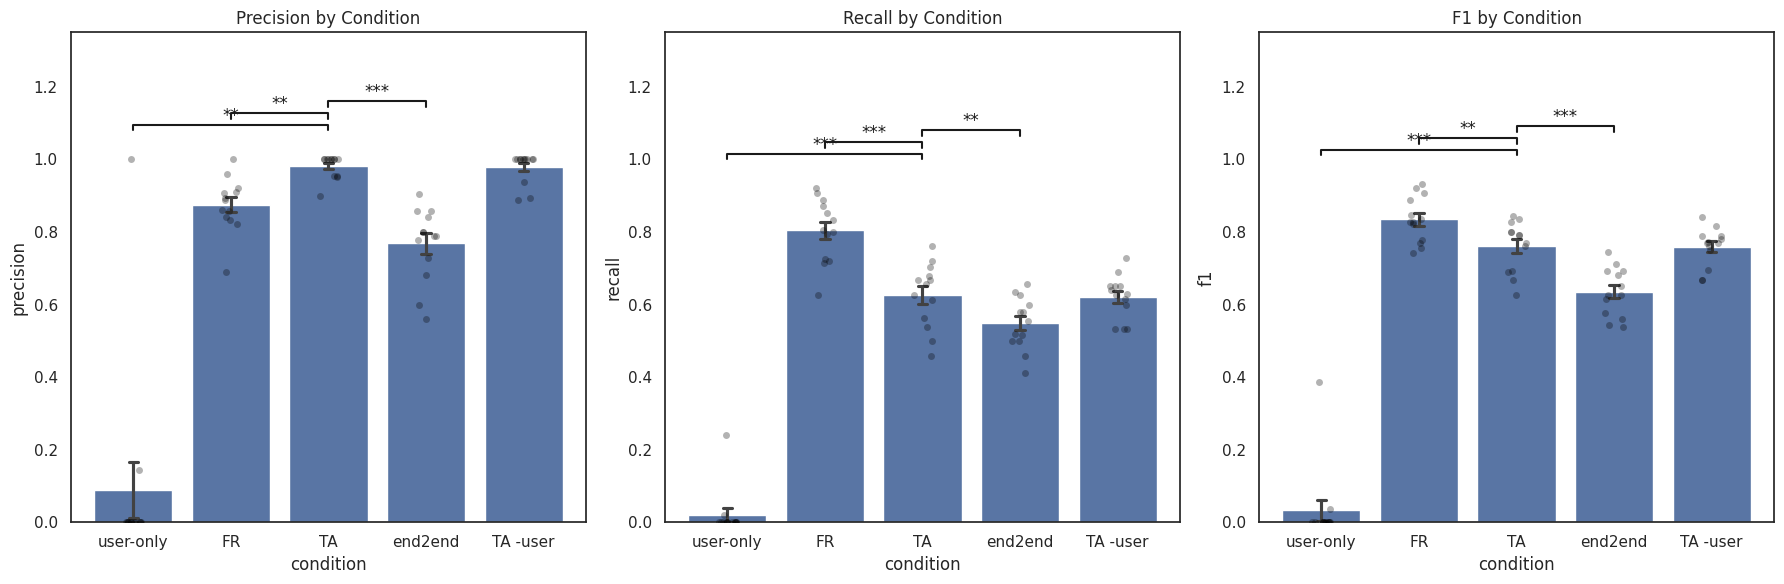

In [14]:
# Visualization for P/R/F1
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_df = df
conditions_list = list(conditions)

for i, metric in enumerate(metrics_pr):
    sns.barplot(data=plot_df, x='condition', y=metric, ax=axes[i], capsize=.1, errorbar='se', order=conditions_list)
    sns.stripplot(data=plot_df, x='condition', y=metric, ax=axes[i], color='black', alpha=0.3, order=conditions_list)
    
    axes[i].set_title(f"{metric.capitalize()} by Condition")
    axes[i].set_ylim(0, 1.35)
    
    # Add post-hoc significance markers if available
    metric_posthoc = posthoc_pr_df[posthoc_pr_df['Metric'] == metric]
    if not metric_posthoc.empty:
        max_y = df[metric].max()
        y_offset = 0.08
        curr_y = max_y + y_offset
        
        idx_map = {c: idx for idx, c in enumerate(conditions_list)}
        
        for _, row in metric_posthoc.iterrows():
            p_adj = row['p-adj']
            p1_name, p2_name = row['Comparison'].split(' vs ')
            if p_adj < 0.05:
                annotate_stats(axes[i], p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
                curr_y += y_offset * 0.4

plt.tight_layout()
plt.show()

### 4.3 Analysis: IAC and Costs


In [15]:
# Append the end2end condition from gpt5-6-terra as a separate condition for IAC analysis (TOST)
df_gpt5_end2end = df_all[(df_all["model"] == "gpt5-6-terra") & (df_all["condition"] == "end2end")].copy()
df_gpt5_end2end["condition"] = "end2end (5.6-terra)"

df_iac = pd.concat([df, df_gpt5_end2end], ignore_index=True)
df_wide_iac = df_iac.pivot(index='participant_id', columns='condition')
df_wide_iac.index = df_wide_iac.index.astype(str)

conditions_iac = ["user-only", "FR", "TA", "end2end", "TA -user", 
"end2end (5.6-terra)",
]

from itertools import combinations

metrics_iac = ['iac_combined_cost', 'iac_misinformation_cost', 'iac_cost_saved', "communicative_compression"]
results_iac = []
posthoc_results = []

pairs = [
    ("user-only", "TA"),
    ("FR", "TA"),
    ("TA", "end2end"),
    ("TA", "TA -user"),
]

for metric in metrics_iac:
    data = [df_wide_iac[metric][c] for c in conditions_iac]

    # Remove participants with any NaNs in these columns
    mask = ~(data[0].isna() | data[1].isna() | data[2].isna())
    data = [d[mask] for d in data]
    if len(data[0]) < 2:
        continue
        
    stat, p = stats.friedmanchisquare(*data)
    w = calculate_kendall_w(stat, len(data[0]), len(conditions_iac))
    
    results_iac.append({
        'Metric': metric,
        'Friedman Stat': stat,
        'p-value': p,
        'Kendall\'s W': w
    })
    
    # Post-hoc if significant
    if p < 0.05:
        p_vals = []
        medians = []
        w_stats = []
        r_vals = []
        for p1, p2 in pairs:
            pair_mask = ~(df_wide_iac[metric][p1].isna() | df_wide_iac[metric][p2].isna())
            w_stat, pp = stats.wilcoxon(df_wide_iac[metric][p1][pair_mask], df_wide_iac[metric][p2][pair_mask])
            p_vals.append(pp)
            medians.append((df_wide_iac[metric][p1][pair_mask].median(), df_wide_iac[metric][p2][pair_mask].median()))
            w_stats.append(w_stat)
            r_val = calculate_rank_biserial(w_stat, pair_mask.sum())
            r_vals.append(r_val)
        
        # Holm correction
        _, p_adj, _, _ = multipletests(p_vals, method='holm')
        
        for i, pair in enumerate(pairs):
            posthoc_results.append({
                'Metric': metric,
                'Comparison': f"{pair[0]} vs {pair[1]}",
                'Median 1': medians[i][0],
                'Median 2': medians[i][1],
                'Wilcoxon W': w_stats[i],
                'p-adj': p_adj[i],
                'Effect Size (r)': r_vals[i]
            })

results_iac_df = pd.DataFrame(results_iac)
posthoc_df = pd.DataFrame(posthoc_results)

print("IAC / Cost Statistical Results (Friedman Test):")
display(results_iac_df)
if not posthoc_df.empty:
    print("\nPost-hoc Wilcoxon (Holm-corrected):")
    display(posthoc_df)


IAC / Cost Statistical Results (Friedman Test):


,Metric,Friedman Stat,p-value,Kendall's W
0,iac_combined_cost,40.356295,1.265597e-07,0.620866
1,iac_misinformation_cost,40.500000,1.183843e-07,0.623077
2,iac_cost_saved,43.437500,3.012439e-08,0.668269
3,communicative_compression,44.690265,1.677201e-08,0.687543



Post-hoc Wilcoxon (Holm-corrected):


,Metric,Comparison,Median 1,Median 2,Wilcoxon W,p-adj,Effect Size (r)
0,iac_combined_cost,user-only vs TA,773.500000,241.200000,0.0,0.000977,1.000000
1,iac_combined_cost,FR vs TA,233.200000,241.200000,3.0,0.625000,0.934066
2,iac_combined_cost,TA vs end2end,241.200000,626.500000,3.0,0.003662,0.934066
3,iac_combined_cost,TA vs TA -user,241.200000,233.000000,8.0,0.390625,0.824176
4,iac_misinformation_cost,user-only vs TA,45.670000,0.000000,0.0,0.046875,1.000000
5,iac_misinformation_cost,FR vs TA,0.000000,0.000000,3.0,0.625000,0.934066
6,iac_misinformation_cost,TA vs end2end,0.000000,150.000000,0.0,0.001953,1.000000
7,iac_misinformation_cost,TA vs TA -user,0.000000,0.000000,0.0,0.125000,1.000000
8,iac_cost_saved,user-only vs TA,169.500000,543.800000,0.0,0.000977,1.000000
9,iac_cost_saved,FR vs TA,540.500000,543.800000,0.0,1.000000,1.000000


In [16]:
# # Visualization for IAC Metrics
# fig, axes = plt.subplots(1, len(metrics_iac), figsize=(16, 6))
# if len(metrics_iac) == 1: axes = [axes]

# plot_df = df_iac

# for i, metric in enumerate(metrics_iac):
#     sns.barplot(data=plot_df, x='condition', y=metric, ax=axes[i], capsize=.1, errorbar='se', 
#                 order=conditions_iac)
#     sns.stripplot(data=plot_df, x='condition', y=metric, ax=axes[i], color='black', alpha=0.3,
#                   order=conditions_iac)
    
#     axes[i].set_title(f"{metric.replace('_', ' ').title()}")
    
#     # Add post-hoc significance markers if available
#     metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]
#     if not metric_posthoc.empty:
#         max_y = df_iac[metric].max()
#         # Simple logic for annotations (can be refined)
#         y_offset = max_y * 0.1
#         curr_y = max_y + y_offset
        
#         # Mapping condition names to plot indices
#         idx_map = {c: idx for idx, c in enumerate(conditions_iac)}
        
#         for _, row in metric_posthoc.iterrows():
#             p_adj = row['p-adj']
#             p1_name, p2_name = row['Comparison'].split(' vs ')
#             if p_adj < 0.05:
#                 annotate_stats(axes[i], p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
#                 curr_y += y_offset * 0.4

# axes[0].set_ylabel("IAC Cost Saved (#steps)")
# axes[1].set_ylabel("Communicative compression (#steps / token)")

# plt.tight_layout()
# plt.show()


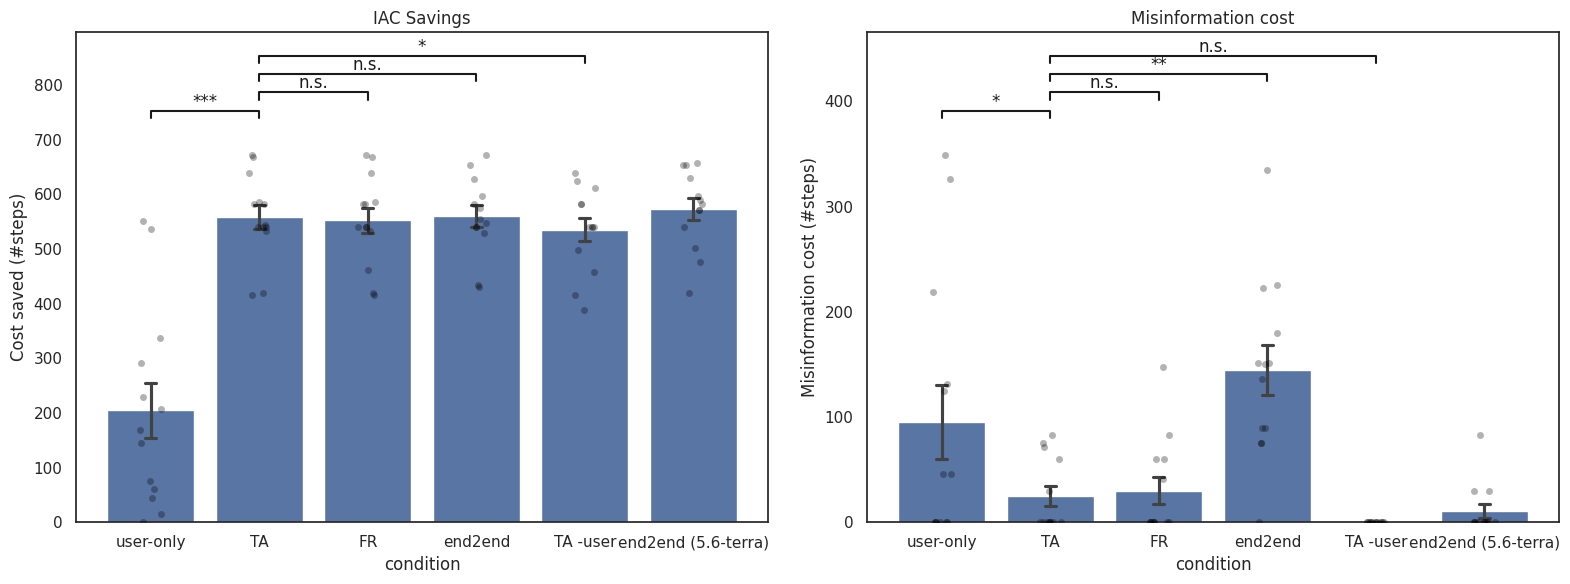

In [17]:
# Create separate figures for pub
conditions_to_plot = ["user-only", "TA", "FR", "end2end", "TA -user", "end2end (5.6-terra)"]
plot_df = df_iac[df_iac['condition'].isin(conditions_to_plot)]
metrics_to_plot = ["iac_cost_saved", "iac_misinformation_cost"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 6))
if len(metrics_to_plot) == 1: axes = [axes]

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(data=plot_df, x='condition', y=metric, ax=axes[i], capsize=.1, errorbar='se', 
                order=conditions_to_plot)
    sns.stripplot(data=plot_df, x='condition', y=metric, ax=axes[i], color='black', alpha=0.3,
                  order=conditions_to_plot)
    
    axes[i].set_title(f"{metric.replace('_', ' ').title()}")
    
    # Add post-hoc significance markers if available
    metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]
    if (metric != "iac_combined_cost") and not metric_posthoc.empty:
        max_y = df_iac[metric].max()
        # Simple logic for annotations (can be refined)
        y_offset = max_y * 0.1
        curr_y = max_y + y_offset
        
        # Mapping condition names to plot indices
        idx_map = {c: idx for idx, c in enumerate(conditions_to_plot)}
        
        for _, row in metric_posthoc.iterrows():
            p_adj = row['p-adj']
            p1_name, p2_name = row['Comparison'].split(' vs ')
            # if p_adj < 0.05:
            if p1_name in conditions_to_plot and p2_name in conditions_to_plot:
                annotate_stats(axes[i], p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
                curr_y += y_offset * 0.5


axes[0].set_ylabel("Cost saved (#steps)")
axes[0].set_title("IAC Savings")

axes[1].set_ylabel("Misinformation cost (#steps)")
axes[1].set_title("Misinformation cost")

plt.tight_layout()
plt.show()


In [18]:
def annotate_stats_inverted(ax, p_value, x1, x2, y, h):
    """Adds significance markers to a plot."""
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        # return
        sig = "n.s."
    
    ax.plot([x1, x1, x2, x2], [y, y-h, y-h, y], lw=1.5, c='k')
    ax.text((x1+x2)*.5, y-h, sig, ha='center', va='top', color='k', fontsize=12)

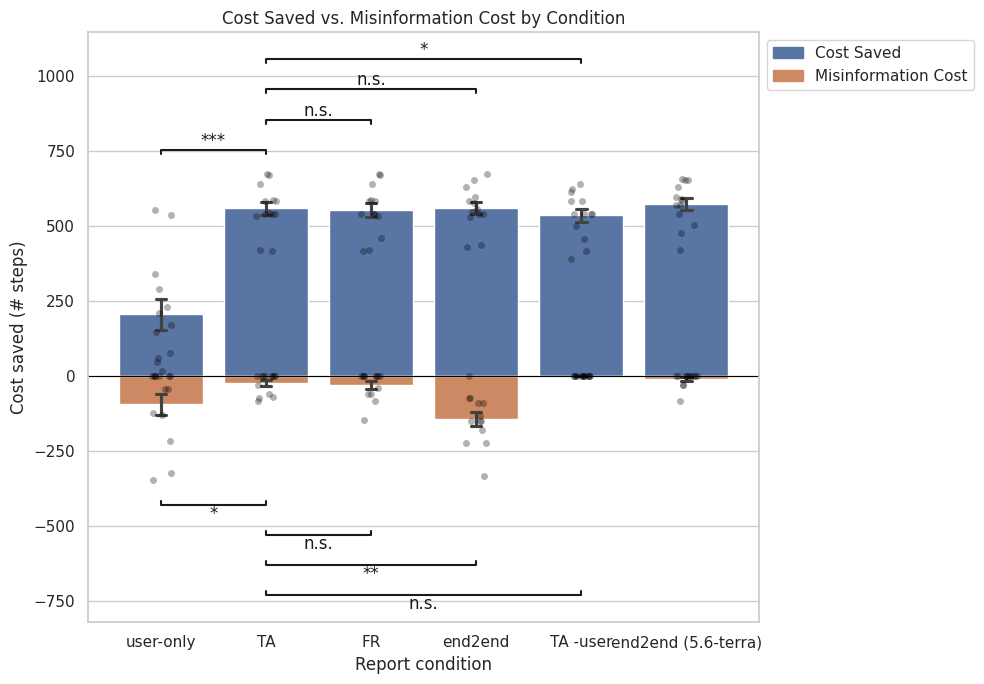

In [19]:
import matplotlib.patches as mpatches

sns.set_theme(style="whitegrid")
df_iac["inverse_misinfo_cost"] = df_iac["iac_misinformation_cost"] * -1
conditions_to_plot = ["user-only", "TA", "FR", "end2end", "TA -user", "end2end (5.6-terra)"]
plot_df = df_iac[df_iac['condition'].isin(conditions_to_plot)]

fig, ax = plt.subplots(figsize=(10, 7))
x = list(range(len(conditions_to_plot)))
width = 0.35

sns.barplot(data=plot_df, x='condition', y="iac_cost_saved", ax=ax, capsize=.1, errorbar='se', 
                order=conditions_to_plot,
                )
sns.stripplot(data=plot_df, x='condition', y="iac_cost_saved", ax=ax, color='black', alpha=0.3,
                order=conditions_to_plot)
    
sns.barplot(data=plot_df, x='condition', y="inverse_misinfo_cost", ax=ax, capsize=.1, errorbar='se', 
                order=conditions_to_plot,
                )
sns.stripplot(data=plot_df, x='condition', y="inverse_misinfo_cost", ax=ax, color='black', alpha=0.3,
                order=conditions_to_plot)
    

# # Add post-hoc significance markers if available
idx_map = {c: idx for idx, c in enumerate(conditions_to_plot)}

# for positive (cost_saved)
metric = "iac_cost_saved"
metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]

max_y = plot_df[metric].max()
y_offset = max_y * 0.1
curr_y = max_y + y_offset

for _, row in metric_posthoc.iterrows():
    p_adj = row['p-adj']
    p1_name, p2_name = row['Comparison'].split(' vs ')
    if p1_name in conditions_to_plot and p2_name in conditions_to_plot:
        annotate_stats(ax, p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
        curr_y += (y_offset * 1.5)

# for negative (misinfo cost)
metric = "iac_misinformation_cost"
metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]
max_y = plot_df[metric].max()
curr_y = max_y * -1 - y_offset
for _, row in metric_posthoc.iterrows():
    p_adj = row['p-adj']
    p1_name, p2_name = row['Comparison'].split(' vs ')
    if p1_name in conditions_to_plot and p2_name in conditions_to_plot:
        annotate_stats_inverted(ax, p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
        curr_y -= (y_offset * 1.5)


ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Cost saved (# steps)")
ax.set_xlabel("Report condition")
ax.set_title("Cost Saved vs. Misinformation Cost by Condition")

cost_saved_color = ax.patches[0].get_facecolor()
misinfo_color = ax.patches[len(conditions_to_plot)].get_facecolor()

cost_saved_patch = mpatches.Patch(color=cost_saved_color, label='Cost Saved')
misinfo_patch = mpatches.Patch(color=misinfo_color, label='Misinformation Cost')

ax.legend(handles=[cost_saved_patch, misinfo_patch], bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()


### 4.4 Correlation Analysis: Content Makeup vs. Performance


State Tokens vs. IAC Cost Saved:
  Pearson correlation: r = 0.0220, p = 0.9432
  Spearman correlation: rho = 0.0744, p = 0.8092

State:Knowledge Ratio vs. Soft Recall:
  Pearson correlation: r = -0.0207, p = 0.9466
  Spearman correlation: rho = 0.0165, p = 0.9574


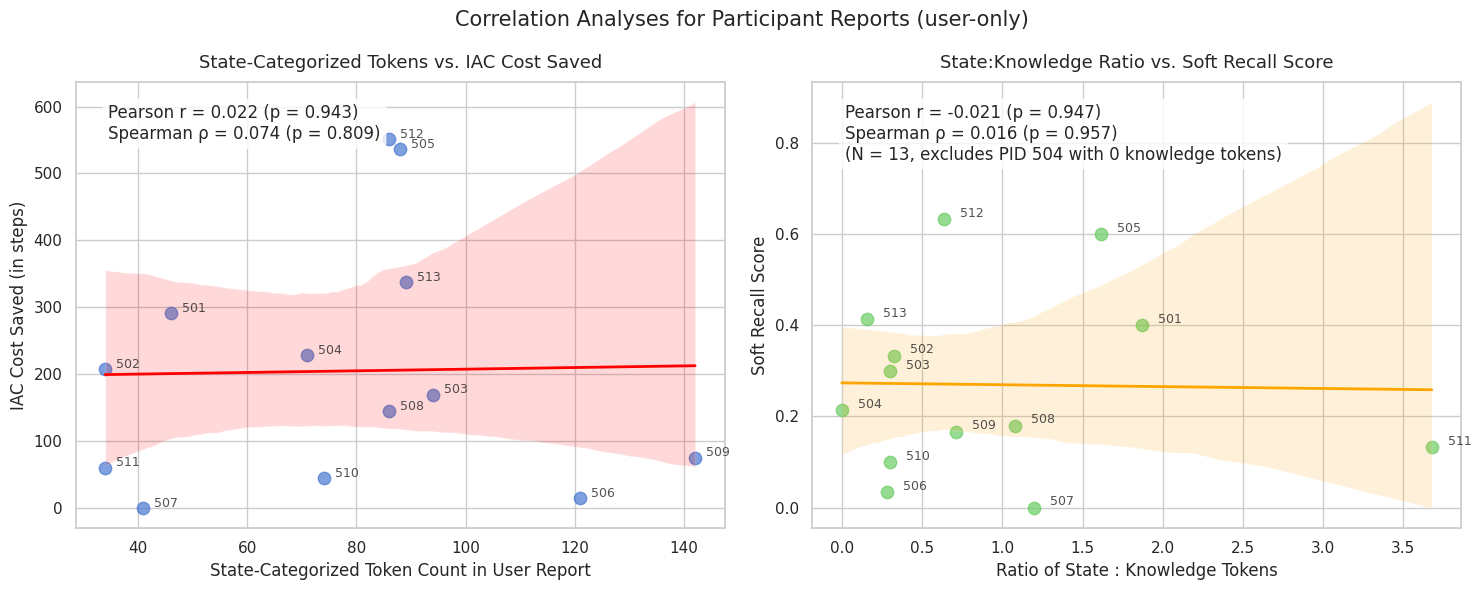

In [20]:
# Ensure participant_id indices are of the same type (string) for clean merging
df_wide.index = df_wide.index.astype(str)
content_df.index = content_df.index.astype(str)

# Create merged dataframe
merged_df = pd.DataFrame({
    'state_tokens': content_df['state'],
    'knowledge_tokens': content_df['knowledge'],
    'iac_cost_saved': df_wide[('iac_cost_saved', 'user-only')],
    'soft_recall': df_wide[('soft_recall', 'user-only')]
})

# Calculate state:knowledge ratio (handling division by zero by converting inf to NaN)
# merged_df['state_knowledge_ratio'] = merged_df['state_tokens'] / merged_df['knowledge_tokens']
merged_df['state_knowledge_ratio'] = merged_df['knowledge_tokens'] / merged_df['state_tokens']
merged_df_clean = merged_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['state_knowledge_ratio', 'soft_recall'])

# Calculate correlations
pearson_r1, pearson_p1 = stats.pearsonr(merged_df['state_tokens'], merged_df['iac_cost_saved'])
spearman_r1, spearman_p1 = stats.spearmanr(merged_df['state_tokens'], merged_df['iac_cost_saved'])

pearson_r2, pearson_p2 = stats.pearsonr(merged_df_clean['state_knowledge_ratio'], merged_df_clean['soft_recall'])
spearman_r2, spearman_p2 = stats.spearmanr(merged_df_clean['state_knowledge_ratio'], merged_df_clean['soft_recall'])

print(f"State Tokens vs. IAC Cost Saved:")
print(f"  Pearson correlation: r = {pearson_r1:.4f}, p = {pearson_p1:.4f}")
print(f"  Spearman correlation: rho = {spearman_r1:.4f}, p = {spearman_p1:.4f}")
print(f"\nState:Knowledge Ratio vs. Soft Recall:")
print(f"  Pearson correlation: r = {pearson_r2:.4f}, p = {pearson_p2:.4f}")
print(f"  Spearman correlation: rho = {spearman_r2:.4f}, p = {spearman_p2:.4f}")

# Plotting
sns.set_theme(style='whitegrid', palette='muted')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: State Tokens vs. IAC Cost Saved
sns.regplot(data=merged_df, x='state_tokens', y='iac_cost_saved', ax=ax1,
            scatter_kws={'s': 80, 'alpha': 0.7, 'color': 'b'}, 
            line_kws={'color': 'red', 'linewidth': 2})
for pid in merged_df.index:
    ax1.text(merged_df.loc[pid, 'state_tokens'] + 2, 
             merged_df.loc[pid, 'iac_cost_saved'] + 2, 
             str(pid), fontsize=9, alpha=0.8)
ax1.set_xlabel('State-Categorized Token Count in User Report', fontsize=12)
ax1.set_ylabel('IAC Cost Saved (in steps)', fontsize=12)
ax1.set_title('State-Categorized Tokens vs. IAC Cost Saved', fontsize=13, pad=10)
ax1.text(0.05, 0.95, f'Pearson r = {pearson_r1:.3f} (p = {pearson_p1:.3f})\nSpearman ρ = {spearman_r1:.3f} (p = {spearman_p1:.3f})',
         transform=ax1.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Right plot: State:Knowledge Ratio vs. Soft Recall
sns.regplot(data=merged_df_clean, x='state_knowledge_ratio', y='soft_recall', ax=ax2,
            scatter_kws={'s': 80, 'alpha': 0.7, 'color': 'g'}, 
            line_kws={'color': 'orange', 'linewidth': 2})
for pid in merged_df_clean.index:
    ax2.text(merged_df_clean.loc[pid, 'state_knowledge_ratio'] + 0.1, 
             merged_df_clean.loc[pid, 'soft_recall'] + 0.005, 
             str(pid), fontsize=9, alpha=0.8)
ax2.set_xlabel('Ratio of State : Knowledge Tokens', fontsize=12)
ax2.set_ylabel('Soft Recall Score', fontsize=12)
ax2.set_title('State:Knowledge Ratio vs. Soft Recall Score', fontsize=13, pad=10)
ax2.text(0.05, 0.95, f'Pearson r = {pearson_r2:.3f} (p = {pearson_p2:.3f})\nSpearman ρ = {spearman_r2:.3f} (p = {spearman_p2:.3f})\n(N = {len(merged_df_clean)}, excludes PID 504 with 0 knowledge tokens)',
         transform=ax2.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Correlation Analyses for Participant Reports (user-only)', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

### 4.5 Ablation Performance Comparison: GPT-4.1-Mini vs. GPT-5.6-Terra

We directly compare the performance of **GPT-4.1-Mini** and **GPT-5.6-Terra** under the end-to-end ablation (`end2end`) condition. Since the same set of participants was evaluated with both models, we perform a paired Wilcoxon signed-rank test to determine if the performance differences are statistically significant.

Paired Comparison: GPT-4.1-Mini vs. GPT-5.6-Terra (End-to-End Ablation)


,Metric,GPT-4.1-Mini (Mean),GPT-4.1-Mini (Median),GPT-5.6-Terra (Mean),GPT-5.6-Terra (Median),Wilcoxon W,p-value
0,Soft Precision,0.703,0.692,0.973,1.000,0.0,0.0005
1,Soft Recall,0.623,0.600,0.651,0.633,10.5,0.1836
2,Soft F1 Score,0.655,0.644,0.777,0.776,4.0,0.0015
3,IAC Combined Cost,648.323,626.500,234.162,203.200,1.0,0.0005
4,Omission Cost Share (%),38.3%,35.0%,90.3%,100.0%,0.0,0.0005
5,Misinformation Cost Share (%),61.7%,65.0%,9.7%,0.0%,0.0,0.0005


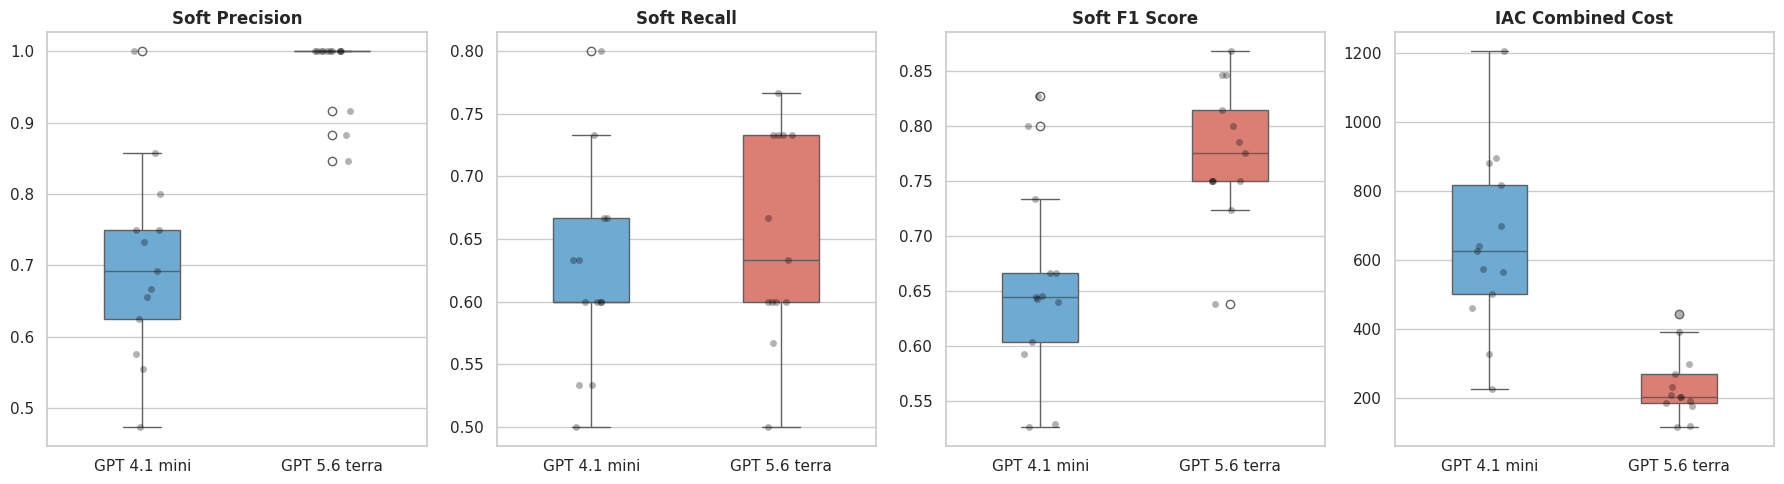

In [21]:
# Extract end2end for both models
df_g4 = df_all[(df_all["model"] == "gpt4-1-mini") & (df_all["condition"] == "end2end")].set_index("participant_id")
df_g5 = df_all[(df_all["model"] == "gpt5-6-terra") & (df_all["condition"] == "end2end")].set_index("participant_id")

common_pids = df_g4.index.intersection(df_g5.index)
df_g4 = df_g4.loc[common_pids]
df_g5 = df_g5.loc[common_pids]

comparison_data = []
metrics = ["soft_precision", "soft_recall", "soft_f1", "iac_combined_cost", "omission_share_pct", "misinformation_share_pct"]
metric_names = {
    "soft_precision": "Soft Precision",
    "soft_recall": "Soft Recall",
    "soft_f1": "Soft F1 Score",
    "iac_combined_cost": "IAC Combined Cost",
    "omission_share_pct": "Omission Cost Share (%)",
    "misinformation_share_pct": "Misinformation Cost Share (%)"
}

for m in metrics:
    stat, p = stats.wilcoxon(df_g4[m], df_g5[m])
    
    # Format percent vs decimal metrics
    is_pct = "%" in metric_names[m]
    g4_mean = f"{df_g4[m].mean():.1f}%" if is_pct else f"{df_g4[m].mean():.3f}"
    g4_med = f"{df_g4[m].median():.1f}%" if is_pct else f"{df_g4[m].median():.3f}"
    g5_mean = f"{df_g5[m].mean():.1f}%" if is_pct else f"{df_g5[m].mean():.3f}"
    g5_med = f"{df_g5[m].median():.1f}%" if is_pct else f"{df_g5[m].median():.3f}"
    
    comparison_data.append({
        "Metric": metric_names[m],
        "GPT-4.1-Mini (Mean)": g4_mean,
        "GPT-4.1-Mini (Median)": g4_med,
        "GPT-5.6-Terra (Mean)": g5_mean,
        "GPT-5.6-Terra (Median)": g5_med,
        "Wilcoxon W": stat,
        "p-value": f"{p:.4f}" if p >= 0.0001 else "< 0.0001"
    })

df_comparison = pd.DataFrame(comparison_data)
print("Paired Comparison: GPT-4.1-Mini vs. GPT-5.6-Terra (End-to-End Ablation)")
display(df_comparison)

# Plotting the comparisons side-by-side
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
plot_metrics = ["soft_precision", "soft_recall", "soft_f1", "iac_combined_cost"]
titles = ["Soft Precision", "Soft Recall", "Soft F1 Score", "IAC Combined Cost"]

# Melt ablation data for seaborn boxplot plotting
df_ablation = df_all[df_all["condition"] == "end2end"].copy()
df_ablation["Model"] = df_ablation["model"].map({"gpt4-1-mini": "GPT 4.1 mini", "gpt5-6-terra": "GPT 5.6 terra"})

for i, m in enumerate(plot_metrics):
    sns.boxplot(
        data=df_ablation, 
        x="Model", 
        y=m, 
        hue="Model",
        ax=axes[i],
        palette={"GPT 4.1 mini": "#5DADE2", "GPT 5.6 terra": "#EC7063"},
        width=0.4,
        legend=False
    )
    sns.stripplot(
        data=df_ablation, 
        x="Model", 
        y=m, 
        ax=axes[i], 
        color="black", 
        alpha=0.3, 
        jitter=0.1
    )
    axes[i].set_title(titles[i], fontsize=12, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()


## 5. Analysis for Model: GPT-5.6-Terra


In [22]:
selected_model = "gpt5-6-terra"
df = df_all[df_all["model"] == selected_model].copy()
df_wide = df.pivot(index='participant_id', columns='condition')
df_wide.index = df_wide.index.astype(str)
print(f"Loaded metrics for {len(df_wide)} participants for model: {selected_model}")


Loaded metrics for 13 participants for model: gpt5-6-terra


### 5.1 Summary Statistics


In [23]:
create_summary_table(df)


Misinformation multiplier (alpha) used in calculations: 3.0

Information Access Cost (IAC) Summary Table:


,Condition,Median Combined Cost,Range Combined Cost,Median Omission Share (%),Range Omission Share (%),Median Misinformation Share (%),Range Misinformation Share (%)
0,user-only,830.46,"[222.50, 1745.74]",84.7%,"[40.0%, 100.0%]",15.3%,"[0.0%, 60.0%]"
1,FR,233.20,"[120.00, 482.00]",100.0%,"[48.3%, 100.0%]",0.0%,"[0.0%, 51.7%]"
2,TA,233.20,"[101.50, 485.90]",100.0%,"[36.8%, 100.0%]",0.0%,"[0.0%, 63.2%]"
3,end2end,203.20,"[116.50, 444.40]",100.0%,"[36.5%, 100.0%]",0.0%,"[0.0%, 63.5%]"
4,TA -user,233.00,"[135.00, 384.40]",100.0%,"[100.0%, 100.0%]",0.0%,"[0.0%, 0.0%]"


### 5.2 Analysis: Precision, Recall, and F1


In [24]:
metrics_pr = ['precision', 'recall', 'f1']
results_pr = []
posthoc_pr_results = []

pairs = [
    ("user-only", "TA"),
    ("FR", "TA"),
    ("TA", "end2end"),
    ("TA", "TA -user")
]

for metric in metrics_pr:
    data = [df_wide[metric][c] for c in conditions]

    # Remove participants with any NaNs in these columns
    mask = ~(data[0].isna() | data[1].isna() | data[2].isna())
    data = [d[mask] for d in data]
    if len(data[0]) < 2:
        continue
        
    stat, p = stats.friedmanchisquare(*data)
    w = calculate_kendall_w(stat, len(data[0]), len(conditions))
    
    results_pr.append({
        'Metric': metric,
        'Friedman Stat': stat,
        'p-value': p,
        'Kendall\'s W': w
    })
    
    # Post-hoc if significant
    if p < 0.05:
        p_vals = []
        medians = []
        w_stats = []
        r_vals = []
        for p1, p2 in pairs:
            pair_mask = ~(df_wide[metric][p1].isna() | df_wide[metric][p2].isna())
            w_stat, pp = stats.wilcoxon(df_wide[metric][p1][pair_mask], df_wide[metric][p2][pair_mask])
            p_vals.append(pp)
            medians.append((df_wide[metric][p1][pair_mask].median(), df_wide[metric][p2][pair_mask].median()))
            w_stats.append(w_stat)
            r_val = calculate_rank_biserial(w_stat, pair_mask.sum())
            r_vals.append(r_val)
        
        # Holm correction
        _, p_adj, _, _ = multipletests(p_vals, method='holm')
        
        for i, pair in enumerate(pairs):
            posthoc_pr_results.append({
                'Metric': metric,
                'Comparison': f"{pair[0]} vs {pair[1]}",
                'Median 1': medians[i][0],
                'Median 2': medians[i][1],
                'Wilcoxon W': w_stats[i],
                'p-adj': p_adj[i],
                'Effect Size (r)': r_vals[i]
            })

results_pr_df = pd.DataFrame(results_pr)
posthoc_pr_df = pd.DataFrame(posthoc_pr_results)

print("Precision / Recall / F1 Statistical Results (Friedman Test):")
display(results_pr_df)
if not posthoc_pr_df.empty:
    print("\nPost-hoc Wilcoxon (Holm-corrected):")
    display(posthoc_pr_df)

Precision / Recall / F1 Statistical Results (Friedman Test):


,Metric,Friedman Stat,p-value,Kendall's W
0,precision,44.751020,4.479200e-09,0.860597
1,recall,48.692913,6.766833e-10,0.936402
2,f1,46.961240,1.553526e-09,0.903101



Post-hoc Wilcoxon (Holm-corrected):


,Metric,Comparison,Median 1,Median 2,Wilcoxon W,p-adj,Effect Size (r)
0,precision,user-only vs TA,0.000000,1.000000,0.0,0.000977,1.000000
1,precision,FR vs TA,0.866667,1.000000,0.0,0.000977,1.000000
2,precision,TA vs end2end,1.000000,0.941176,7.0,0.037109,0.846154
3,precision,TA vs TA -user,1.000000,1.000000,6.0,0.750000,0.868132
4,recall,user-only vs TA,0.000000,0.633333,0.0,0.000977,1.000000
5,recall,FR vs TA,0.820513,0.633333,0.0,0.000977,1.000000
6,recall,TA vs end2end,0.633333,0.592593,0.0,0.003906,1.000000
7,recall,TA vs TA -user,0.633333,0.629630,30.0,0.504883,0.340659
8,f1,user-only vs TA,0.000000,0.769231,0.0,0.000977,1.000000
9,f1,FR vs TA,0.838710,0.769231,3.0,0.002441,0.934066


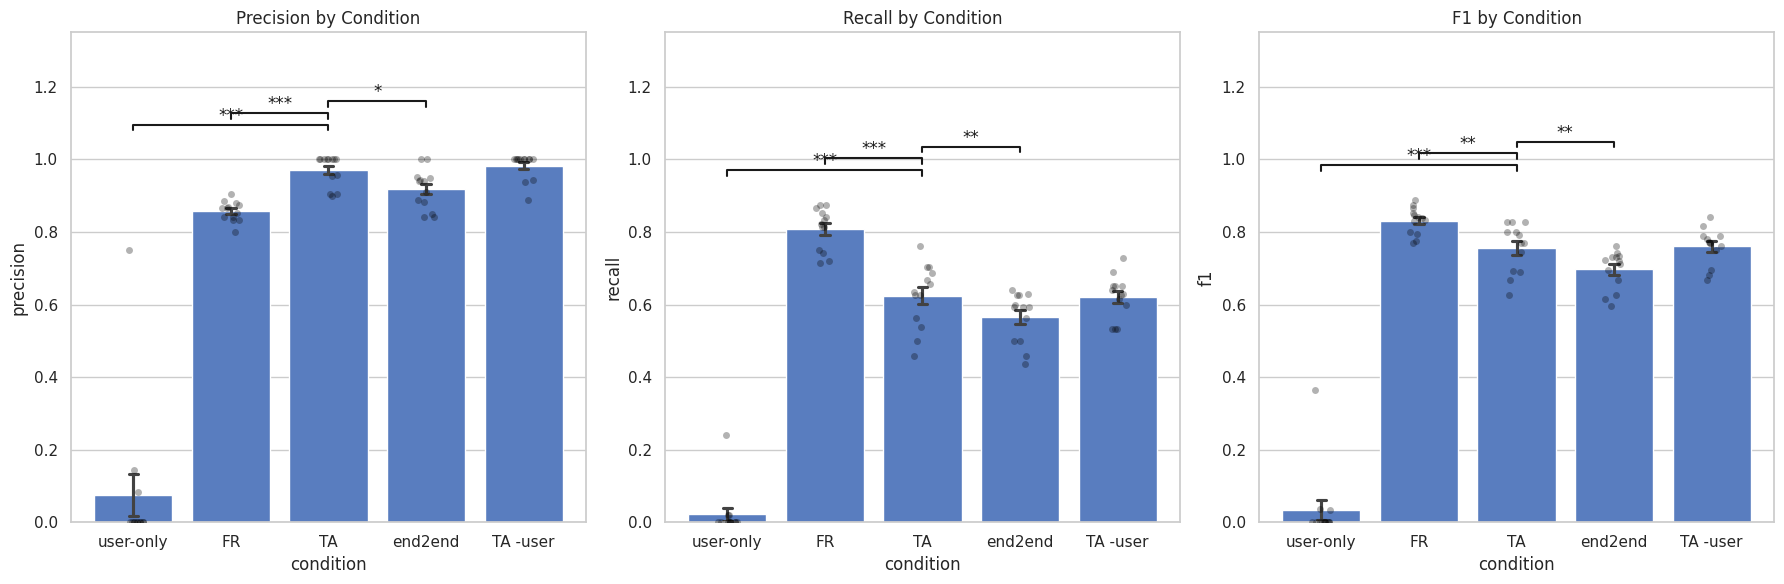

In [25]:
# Visualization for P/R/F1
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
plot_df = df
conditions_list = list(conditions)

for i, metric in enumerate(metrics_pr):
    sns.barplot(data=plot_df, x='condition', y=metric, ax=axes[i], capsize=.1, errorbar='se', order=conditions_list)
    sns.stripplot(data=plot_df, x='condition', y=metric, ax=axes[i], color='black', alpha=0.3, order=conditions_list)
    
    axes[i].set_title(f"{metric.capitalize()} by Condition")
    axes[i].set_ylim(0, 1.35)
    
    # Add post-hoc significance markers if available
    metric_posthoc = posthoc_pr_df[posthoc_pr_df['Metric'] == metric]
    if not metric_posthoc.empty:
        max_y = df[metric].max()
        y_offset = 0.08
        curr_y = max_y + y_offset
        
        idx_map = {c: idx for idx, c in enumerate(conditions_list)}
        
        for _, row in metric_posthoc.iterrows():
            p_adj = row['p-adj']
            p1_name, p2_name = row['Comparison'].split(' vs ')
            if p_adj < 0.05:
                annotate_stats(axes[i], p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
                curr_y += y_offset * 0.4

plt.tight_layout()
plt.show()

### 5.3 Analysis: IAC and Costs


In [26]:
from itertools import combinations

metrics_iac = ['iac_combined_cost', 'iac_misinformation_cost', 'iac_cost_saved', "communicative_compression"]
results_iac = []
posthoc_results = []

pairs = [
    ("user-only", "TA"),
    ("FR", "TA"),
    ("TA", "end2end"),
    ("TA", "TA -user")
]


for metric in metrics_iac:
    data = [df_wide[metric][c] for c in conditions]

    # Remove participants with any NaNs in these columns
    mask = ~(data[0].isna() | data[1].isna() | data[2].isna())
    data = [d[mask] for d in data]
    if len(data[0]) < 2:
        continue
        
    stat, p = stats.friedmanchisquare(*data)
    w = calculate_kendall_w(stat, len(data[0]), len(conditions))
    
    results_iac.append({
        'Metric': metric,
        'Friedman Stat': stat,
        'p-value': p,
        'Kendall\'s W': w
    })
    
    # Post-hoc if significant
    if p < 0.05:
        p_vals = []
        medians = []
        w_stats = []
        r_vals = []
        for p1, p2 in pairs:
            pair_mask = ~(df_wide[metric][p1].isna() | df_wide[metric][p2].isna())
            w_stat, pp = stats.wilcoxon(df_wide[metric][p1][pair_mask], df_wide[metric][p2][pair_mask])
            p_vals.append(pp)
            medians.append((df_wide[metric][p1][pair_mask].median(), df_wide[metric][p2][pair_mask].median()))
            w_stats.append(w_stat)
            r_val = calculate_rank_biserial(w_stat, pair_mask.sum())
            r_vals.append(r_val)
        
        # Holm correction
        _, p_adj, _, _ = multipletests(p_vals, method='holm')
        
        for i, pair in enumerate(pairs):
            posthoc_results.append({
                'Metric': metric,
                'Comparison': f"{pair[0]} vs {pair[1]}",
                'Median 1': medians[i][0],
                'Median 2': medians[i][1],
                'Wilcoxon W': w_stats[i],
                'p-adj': p_adj[i],
                'Effect Size (r)': r_vals[i]
            })

results_iac_df = pd.DataFrame(results_iac)
posthoc_df = pd.DataFrame(posthoc_results)

print("IAC / Cost Statistical Results (Friedman Test):")
display(results_iac_df)
if not posthoc_df.empty:
    print("\nPost-hoc Wilcoxon (Holm-corrected):")
    display(posthoc_df)

IAC / Cost Statistical Results (Friedman Test):


,Metric,Friedman Stat,p-value,Kendall's W
0,iac_combined_cost,31.356522,2.589218e-06,0.603010
1,iac_misinformation_cost,22.040000,1.967792e-04,0.423846
2,iac_cost_saved,38.684685,8.093352e-08,0.743936
3,communicative_compression,34.350195,6.315777e-07,0.660581



Post-hoc Wilcoxon (Holm-corrected):


,Metric,Comparison,Median 1,Median 2,Wilcoxon W,p-adj,Effect Size (r)
0,iac_combined_cost,user-only vs TA,830.460000,233.200000,0.0,0.000977,1.000000
1,iac_combined_cost,FR vs TA,233.200000,233.200000,6.0,1.000000,0.868132
2,iac_combined_cost,TA vs end2end,233.200000,203.200000,27.0,1.000000,0.406593
3,iac_combined_cost,TA vs TA -user,233.200000,233.000000,21.0,1.000000,0.538462
4,iac_misinformation_cost,user-only vs TA,45.670000,0.000000,0.0,0.062500,1.000000
5,iac_misinformation_cost,FR vs TA,0.000000,0.000000,0.0,1.000000,1.000000
6,iac_misinformation_cost,TA vs end2end,0.000000,0.000000,1.0,1.000000,0.978022
7,iac_misinformation_cost,TA vs TA -user,0.000000,0.000000,0.0,0.750000,1.000000
8,iac_cost_saved,user-only vs TA,75.000000,558.800000,0.0,0.000977,1.000000
9,iac_cost_saved,FR vs TA,540.500000,558.800000,0.0,0.500000,1.000000


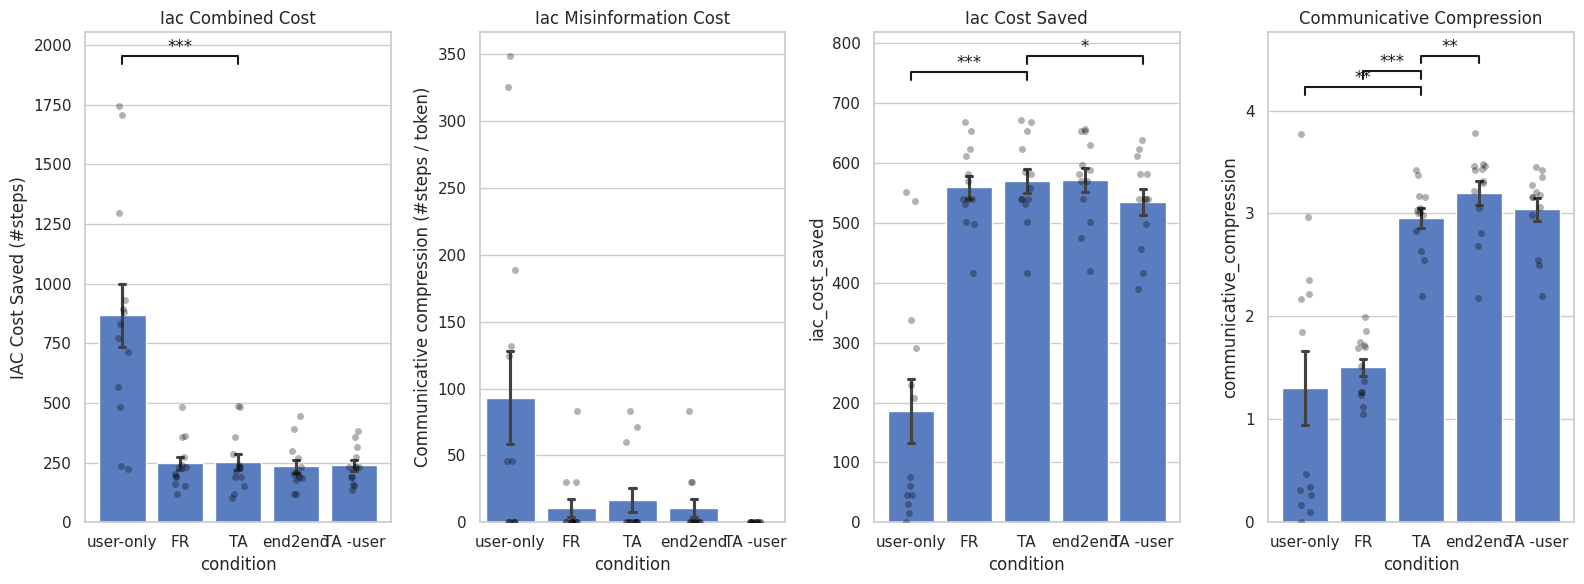

In [27]:
# Visualization for IAC Metrics
fig, axes = plt.subplots(1, len(metrics_iac), figsize=(16, 6))
if len(metrics_iac) == 1: axes = [axes]

# Create a 'raw' condition dataframe to include in the plot
# raw_df = df.drop_duplicates(subset=['participant_id']).copy()
# raw_df['condition'] = 'raw'
# for m in metrics_iac:
#     if f'raw_{m}' in raw_df.columns:
#         raw_df[m] = raw_df[f'raw_{m}']
# plot_df = pd.concat([df[df['condition'].isin(['user_report', 'task_aware', 'full_realization'])], raw_df], ignore_index=True)
plot_df = df


for i, metric in enumerate(metrics_iac):
    sns.barplot(data=plot_df, x='condition', y=metric, ax=axes[i], capsize=.1, errorbar='se', 
                order=conditions)
    sns.stripplot(data=plot_df, x='condition', y=metric, ax=axes[i], color='black', alpha=0.3,
                  order=conditions)
    
    axes[i].set_title(f"{metric.replace('_', ' ').title()}")
    
    # Add post-hoc significance markers if available
    metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]
    if not metric_posthoc.empty:
        max_y = df[metric].max()
        # Simple logic for annotations (can be refined)
        y_offset = max_y * 0.1
        curr_y = max_y + y_offset
        
        # Mapping condition names to plot indices (order: raw, user_report, task_aware, full_realization)
        idx_map = {c: idx for idx, c in enumerate(conditions)}
        
        for _, row in metric_posthoc.iterrows():
            p_adj = row['p-adj']
            p1_name, p2_name = row['Comparison'].split(' vs ')
            if p_adj < 0.05:
                annotate_stats(axes[i], p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
                curr_y += y_offset * 0.4

axes[0].set_ylabel("IAC Cost Saved (#steps)")
axes[1].set_ylabel("Communicative compression (#steps / token)")

plt.tight_layout()
plt.show()

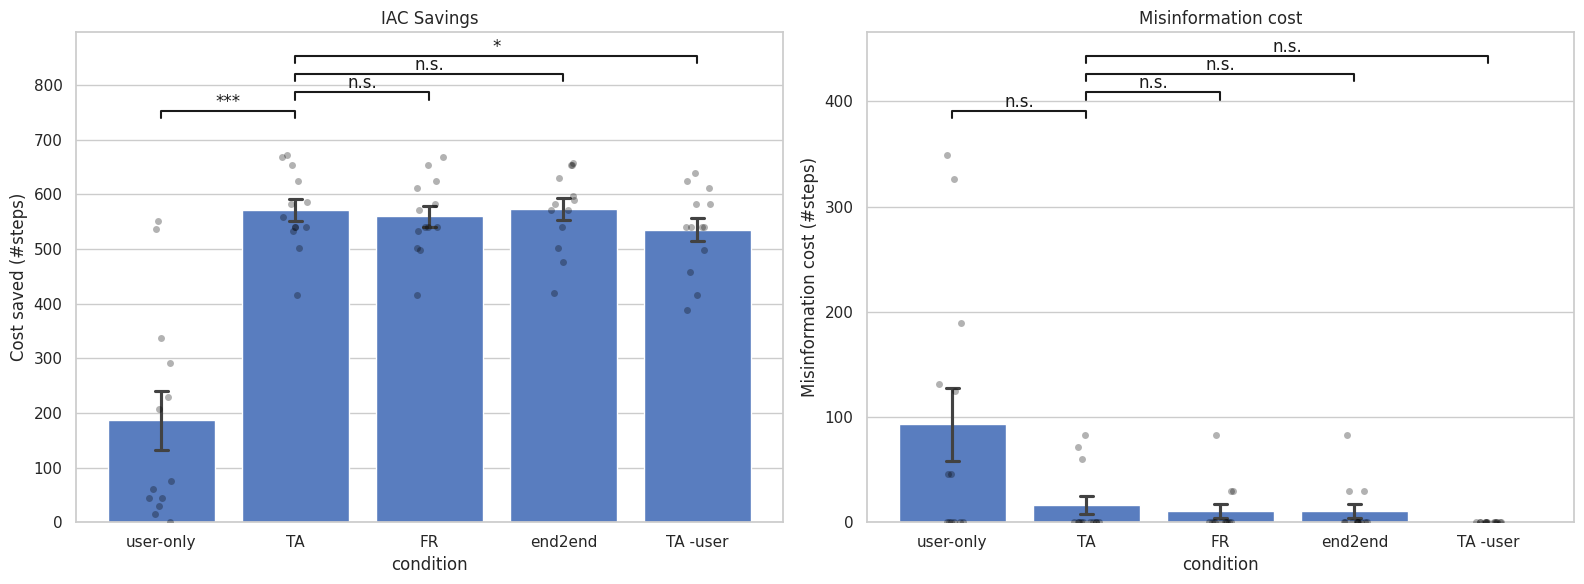

In [28]:
# Create separate figures for pub
conditions_to_plot = ["user-only", "TA", "FR", "end2end", "TA -user"]
plot_df = df[df['condition'].isin(conditions_to_plot)]
metrics_to_plot = ["iac_cost_saved", "iac_misinformation_cost"]
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(16, 6))
if len(metrics_to_plot) == 1: axes = [axes]

for i, metric in enumerate(metrics_to_plot):
    sns.barplot(data=plot_df, x='condition', y=metric, ax=axes[i], capsize=.1, errorbar='se', 
                order=conditions_to_plot)
    sns.stripplot(data=plot_df, x='condition', y=metric, ax=axes[i], color='black', alpha=0.3,
                  order=conditions_to_plot)
    
    axes[i].set_title(f"{metric.replace('_', ' ').title()}")
    
    # Add post-hoc significance markers if available
    metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]
    if (metric != "iac_combined_cost") and not metric_posthoc.empty:
        max_y = df[metric].max()
        # Simple logic for annotations (can be refined)
        y_offset = max_y * 0.1
        curr_y = max_y + y_offset
        
        # Mapping condition names to plot indices
        idx_map = {c: idx for idx, c in enumerate(conditions_to_plot)}
        
        for _, row in metric_posthoc.iterrows():
            p_adj = row['p-adj']
            p1_name, p2_name = row['Comparison'].split(' vs ')
            # if p_adj < 0.05:
            if p1_name in conditions_to_plot and p2_name in conditions_to_plot:
                annotate_stats(axes[i], p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
                curr_y += y_offset * 0.5


axes[0].set_ylabel("Cost saved (#steps)")
axes[0].set_title("IAC Savings")

axes[1].set_ylabel("Misinformation cost (#steps)")
axes[1].set_title("Misinformation cost")

plt.tight_layout()
plt.show()

In [29]:
def annotate_stats_inverted(ax, p_value, x1, x2, y, h):
    """Adds significance markers to a plot."""
    if p_value < 0.001:
        sig = "***"
    elif p_value < 0.01:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        # return
        sig = "n.s."
    
    ax.plot([x1, x1, x2, x2], [y, y-h, y-h, y], lw=1.5, c='k')
    ax.text((x1+x2)*.5, y-h, sig, ha='center', va='top', color='k', fontsize=12)

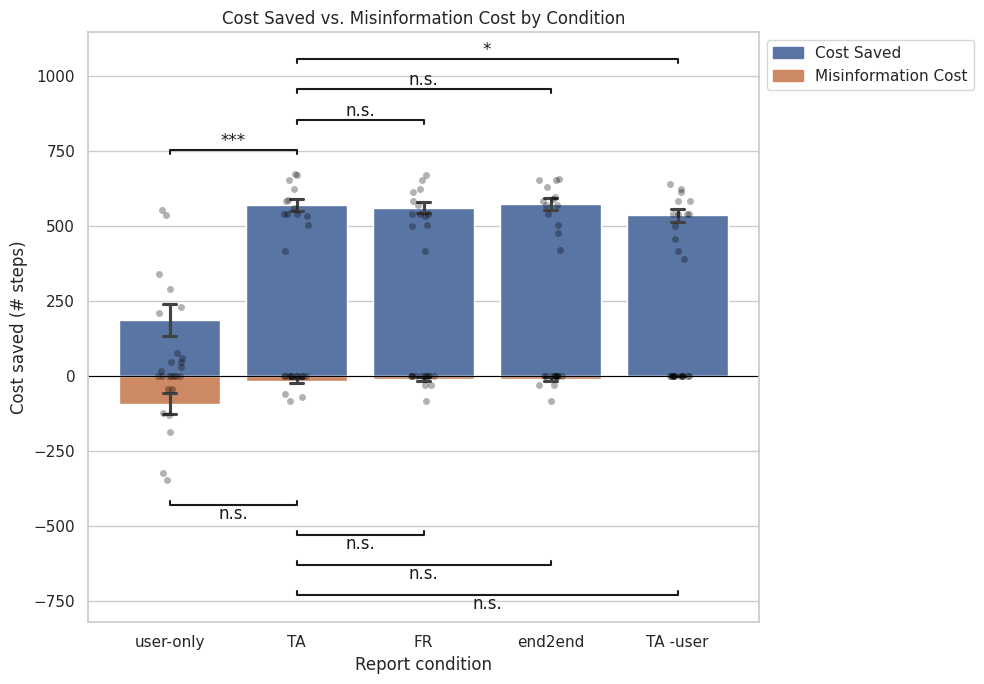

In [30]:
import matplotlib.patches as mpatches


sns.set_theme(style="whitegrid")
df["inverse_misinfo_cost"] = df["iac_misinformation_cost"] * -1
conditions_to_plot = ["user-only", "TA", "FR", "end2end", "TA -user"]
plot_df = df[df['condition'].isin(conditions_to_plot)]
# metrics_to_plot = ["iac_cost_saved", "iac_misinformation_cost"]

fig, ax = plt.subplots(figsize=(10, 7))
# fig, ax = plt.subplots()
x = list(range(len(conditions_to_plot)))
width = 0.35

sns.barplot(data=plot_df, x='condition', y="iac_cost_saved", ax=ax, capsize=.1, errorbar='se', 
                order=conditions_to_plot,
                # color="#6929c4"
                )
sns.stripplot(data=plot_df, x='condition', y="iac_cost_saved", ax=ax, color='black', alpha=0.3,
                order=conditions_to_plot)
    
sns.barplot(data=plot_df, x='condition', y="inverse_misinfo_cost", ax=ax, capsize=.1, errorbar='se', 
                order=conditions_to_plot,
                # color="#1192e8"
                )
sns.stripplot(data=plot_df, x='condition', y="inverse_misinfo_cost", ax=ax, color='black', alpha=0.3,
                order=conditions_to_plot)
    

# # Add post-hoc significance markers if available
idx_map = {c: idx for idx, c in enumerate(conditions_to_plot)}

# for positive (cost_saved)
metric = "iac_cost_saved"
metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]

max_y = plot_df[metric].max()
y_offset = max_y * 0.1
curr_y = max_y + y_offset

for _, row in metric_posthoc.iterrows():
    p_adj = row['p-adj']
    p1_name, p2_name = row['Comparison'].split(' vs ')
    if p1_name in conditions_to_plot and p2_name in conditions_to_plot:
        annotate_stats(ax, p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
        curr_y += (y_offset * 1.5)

# for negative (misinfo cost)
metric = "iac_misinformation_cost"
metric_posthoc = posthoc_df[posthoc_df['Metric'] == metric]
max_y = plot_df[metric].max()
# y_offset = max_y * 0.1
curr_y = max_y * -1 - y_offset
for _, row in metric_posthoc.iterrows():
    p_adj = row['p-adj']
    p1_name, p2_name = row['Comparison'].split(' vs ')
    if p1_name in conditions_to_plot and p2_name in conditions_to_plot:
        annotate_stats_inverted(ax, p_adj, idx_map[p1_name], idx_map[p2_name], curr_y, y_offset*0.2)
        curr_y -= (y_offset * 1.5)


ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Cost saved (# steps)")
ax.set_xlabel("Report condition")
ax.set_title("Cost Saved vs. Misinformation Cost by Condition")
# ax.legend()
# Grab the colors seaborn assigned to each set of bars
cost_saved_color = ax.patches[0].get_facecolor()
misinfo_color = ax.patches[len(conditions_to_plot)].get_facecolor()

cost_saved_patch = mpatches.Patch(color=cost_saved_color, label='Cost Saved')
misinfo_patch = mpatches.Patch(color=misinfo_color, label='Misinformation Cost')

ax.legend(handles=[cost_saved_patch, misinfo_patch], bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

### 5.4 Correlation Analysis: Content Makeup vs. Performance


State Tokens vs. IAC Cost Saved:
  Pearson correlation: r = -0.0195, p = 0.9497
  Spearman correlation: rho = 0.0083, p = 0.9786

State:Knowledge Ratio vs. Soft Recall:
  Pearson correlation: r = 0.0237, p = 0.9387
  Spearman correlation: rho = 0.0413, p = 0.8935


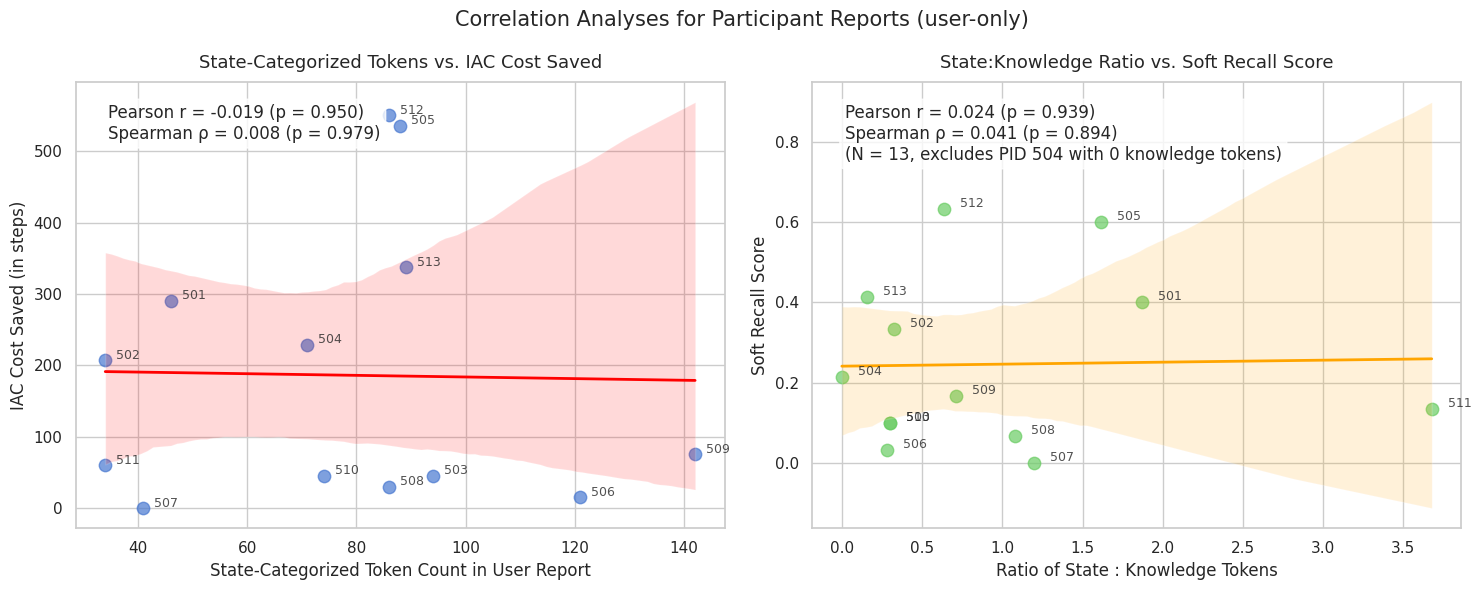

In [31]:
# Ensure participant_id indices are of the same type (string) for clean merging
df_wide.index = df_wide.index.astype(str)
content_df.index = content_df.index.astype(str)

# Create merged dataframe
merged_df = pd.DataFrame({
    'state_tokens': content_df['state'],
    'knowledge_tokens': content_df['knowledge'],
    'iac_cost_saved': df_wide[('iac_cost_saved', 'user-only')],
    'soft_recall': df_wide[('soft_recall', 'user-only')]
})

# Calculate state:knowledge ratio (handling division by zero by converting inf to NaN)
# merged_df['state_knowledge_ratio'] = merged_df['state_tokens'] / merged_df['knowledge_tokens']
merged_df['state_knowledge_ratio'] = merged_df['knowledge_tokens'] / merged_df['state_tokens']
merged_df_clean = merged_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['state_knowledge_ratio', 'soft_recall'])

# Calculate correlations
pearson_r1, pearson_p1 = stats.pearsonr(merged_df['state_tokens'], merged_df['iac_cost_saved'])
spearman_r1, spearman_p1 = stats.spearmanr(merged_df['state_tokens'], merged_df['iac_cost_saved'])

pearson_r2, pearson_p2 = stats.pearsonr(merged_df_clean['state_knowledge_ratio'], merged_df_clean['soft_recall'])
spearman_r2, spearman_p2 = stats.spearmanr(merged_df_clean['state_knowledge_ratio'], merged_df_clean['soft_recall'])

print(f"State Tokens vs. IAC Cost Saved:")
print(f"  Pearson correlation: r = {pearson_r1:.4f}, p = {pearson_p1:.4f}")
print(f"  Spearman correlation: rho = {spearman_r1:.4f}, p = {spearman_p1:.4f}")
print(f"\nState:Knowledge Ratio vs. Soft Recall:")
print(f"  Pearson correlation: r = {pearson_r2:.4f}, p = {pearson_p2:.4f}")
print(f"  Spearman correlation: rho = {spearman_r2:.4f}, p = {spearman_p2:.4f}")

# Plotting
sns.set_theme(style='whitegrid', palette='muted')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left plot: State Tokens vs. IAC Cost Saved
sns.regplot(data=merged_df, x='state_tokens', y='iac_cost_saved', ax=ax1,
            scatter_kws={'s': 80, 'alpha': 0.7, 'color': 'b'}, 
            line_kws={'color': 'red', 'linewidth': 2})
for pid in merged_df.index:
    ax1.text(merged_df.loc[pid, 'state_tokens'] + 2, 
             merged_df.loc[pid, 'iac_cost_saved'] + 2, 
             str(pid), fontsize=9, alpha=0.8)
ax1.set_xlabel('State-Categorized Token Count in User Report', fontsize=12)
ax1.set_ylabel('IAC Cost Saved (in steps)', fontsize=12)
ax1.set_title('State-Categorized Tokens vs. IAC Cost Saved', fontsize=13, pad=10)
ax1.text(0.05, 0.95, f'Pearson r = {pearson_r1:.3f} (p = {pearson_p1:.3f})\nSpearman ρ = {spearman_r1:.3f} (p = {spearman_p1:.3f})',
         transform=ax1.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Right plot: State:Knowledge Ratio vs. Soft Recall
sns.regplot(data=merged_df_clean, x='state_knowledge_ratio', y='soft_recall', ax=ax2,
            scatter_kws={'s': 80, 'alpha': 0.7, 'color': 'g'}, 
            line_kws={'color': 'orange', 'linewidth': 2})
for pid in merged_df_clean.index:
    ax2.text(merged_df_clean.loc[pid, 'state_knowledge_ratio'] + 0.1, 
             merged_df_clean.loc[pid, 'soft_recall'] + 0.005, 
             str(pid), fontsize=9, alpha=0.8)
ax2.set_xlabel('Ratio of State : Knowledge Tokens', fontsize=12)
ax2.set_ylabel('Soft Recall Score', fontsize=12)
ax2.set_title('State:Knowledge Ratio vs. Soft Recall Score', fontsize=13, pad=10)
ax2.text(0.05, 0.95, f'Pearson r = {pearson_r2:.3f} (p = {pearson_p2:.3f})\nSpearman ρ = {spearman_r2:.3f} (p = {spearman_p2:.3f})\n(N = {len(merged_df_clean)}, excludes PID 504 with 0 knowledge tokens)',
         transform=ax2.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Correlation Analyses for Participant Reports (user-only)', fontsize=15, y=0.98)
plt.tight_layout()
plt.show()

## 7. Hodges-Lehmann Analysis: GPT-4.1-Mini TA vs. GPT-5.6-Terra End-to-End

This section computes per-participant differences between the GPT-4.1-mini Task-Aware (TA) condition 
and the GPT-5.6-terra End-to-End (end2end) condition, then applies the Hodges-Lehmann estimator 
with 95% bootstrap confidence intervals on the three IAC metrics.

A **negative difference** (TA - end2end) indicates TA achieves a lower (better) cost than end2end.
The Hodges-Lehmann estimator is the median of all pairwise averages (Walsh averages) of the differences,
providing a robust, non-parametric point estimate of location shift.

In [32]:
import numpy as np
import pandas as pd

# --- Helper: Hodges-Lehmann estimator + bootstrap CI ---
def hodges_lehmann(diffs):
    """Hodges-Lehmann estimator: median of all pairwise Walsh averages."""
    diffs = np.asarray(diffs)
    n = len(diffs)
    walsh = [(diffs[i] + diffs[j]) / 2.0 for i in range(n) for j in range(i, n)]
    return np.median(walsh)

def bootstrap_hl_ci(diffs, n_boot=10000, ci=0.95, seed=42):
    """Bootstrap CI around the Hodges-Lehmann estimate."""
    rng = np.random.default_rng(seed)
    diffs = np.asarray(diffs)
    boot_hl = [hodges_lehmann(rng.choice(diffs, size=len(diffs), replace=True)) for _ in range(n_boot)]
    alpha = (1 - ci) / 2
    return float(np.percentile(boot_hl, 100 * alpha)), float(np.percentile(boot_hl, 100 * (1 - alpha)))

# --- Extract the two conditions ---
df_ta_mini   = df_all[(df_all['model'] == 'gpt4-1-mini') & (df_all['condition'] == 'TA')].copy()
df_e2e_terra = df_all[(df_all['model'] == 'gpt5-6-terra') & (df_all['condition'] == 'end2end')].copy()

# Index by participant
df_ta_mini   = df_ta_mini.set_index('participant_id')
df_e2e_terra = df_e2e_terra.set_index('participant_id')

# Keep only participants present in both conditions
shared_pids = df_ta_mini.index.intersection(df_e2e_terra.index)
print(f'Participants in both conditions: {sorted(shared_pids.tolist())} (N={len(shared_pids)})')

# Compute per-participant difference: TA_mini - end2end_terra
metrics_iac = ['iac_combined_cost', 'iac_cost_saved', 'iac_misinformation_cost']
diff_df = pd.DataFrame(index=shared_pids)
for m in metrics_iac:
    diff_df[m + '_diff'] = df_ta_mini.loc[shared_pids, m] - df_e2e_terra.loc[shared_pids, m]

print('\nPer-participant differences (TA_mini - end2end_terra):')
display(diff_df.round(3))


Participants in both conditions: [501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513] (N=13)

Per-participant differences (TA_mini - end2end_terra):


,iac_combined_cost_diff,iac_cost_saved_diff,iac_misinformation_cost_diff
participant_id,,,
501,0.00,0.0,0.00
502,30.00,-30.0,0.00
503,272.01,-45.0,75.67
504,90.00,-90.0,0.00
505,0.00,0.0,0.00
506,-75.00,-15.0,-30.00
507,60.00,-60.0,0.00
508,75.00,15.0,30.00
509,-30.00,30.0,0.00


In [33]:
# --- Hodges-Lehmann estimation for each IAC metric ---
hl_results = []
for m in metrics_iac:
    col = m + '_diff'
    diffs = diff_df[col].dropna().values
    hl_est = hodges_lehmann(diffs)
    ci_lo, ci_hi = bootstrap_hl_ci(diffs, n_boot=10000, ci=0.95)
    med_ta   = df_ta_mini.loc[shared_pids, m].median()
    med_e2e  = df_e2e_terra.loc[shared_pids, m].median()
    hl_results.append({
        'Metric': m,
        'Median TA (gpt4-1-mini)': round(med_ta, 2),
        'Median E2E (gpt5-6-terra)': round(med_e2e, 2),
        'HL Estimate (TA - E2E)': round(hl_est, 3),
        '95% CI Lower': round(ci_lo, 3),
        '95% CI Upper': round(ci_hi, 3),
        'N': int(len(diffs)),
    })

hl_df = pd.DataFrame(hl_results)
print('Hodges-Lehmann Estimates and 95% Bootstrap CIs (TA_mini - end2end_terra):')
print('(Negative HL estimate => TA has lower cost than end2end)')
display(hl_df)


Hodges-Lehmann Estimates and 95% Bootstrap CIs (TA_mini - end2end_terra):
(Negative HL estimate => TA has lower cost than end2end)


,Metric,Median TA (gpt4-1-mini),Median E2E (gpt5-6-terra),HL Estimate (TA - E2E),95% CI Lower,95% CI Upper,N
0,iac_combined_cost,241.2,203.2,45.0,0.0,99.75,13
1,iac_cost_saved,543.8,582.0,-7.5,-30.0,7.50,13
2,iac_misinformation_cost,0.0,0.0,0.0,0.0,30.00,13


In [34]:
# Compute SESOI as 25% of HL estimate of diff btw baseline and TA (gpt 4.1 mini)
df_user_mini = df_all[(df_all['model'] == 'gpt4-1-mini') & (df_all['condition'] == 'user-only')].copy()

# Index by participant
df_user_mini   = df_user_mini.set_index('participant_id')

# Keep only participants present in both conditions
shared_pids = df_ta_mini.index.intersection(df_user_mini.index)
print(f'Participants in both conditions: {sorted(shared_pids.tolist())} (N={len(shared_pids)})')

# Compute per-participant difference: TA_mini - user mini
metrics_iac = ['iac_combined_cost', 'iac_cost_saved', 'iac_misinformation_cost']
diff_df = pd.DataFrame(index=shared_pids)
for m in metrics_iac:
    diff_df[m + '_diff'] = df_ta_mini.loc[shared_pids, m] - df_user_mini.loc[shared_pids, m]

print('\nPer-participant differences (TA_mini - user_mini):')
display(diff_df.round(3))


Participants in both conditions: [501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513] (N=13)

Per-participant differences (TA_mini - user_mini):


,iac_combined_cost_diff,iac_cost_saved_diff,iac_misinformation_cost_diff
participant_id,,,
501,-291.30,291.30,0.00
502,-332.80,332.80,0.00
503,-1124.33,374.30,-250.01
504,-448.80,311.79,-41.50
505,-4.30,4.30,0.00
506,-760.51,623.50,-45.67
507,-415.60,415.60,0.00
508,-487.67,440.66,-15.67
509,-1504.54,457.30,-349.08


In [35]:
# --- Hodges-Lehmann estimation for each IAC metric ---
hl_results = []
for m in metrics_iac:
    col = m + '_diff'
    diffs = diff_df[col].dropna().values
    hl_est = hodges_lehmann(diffs)
    ci_lo, ci_hi = bootstrap_hl_ci(diffs, n_boot=10000, ci=0.95)
    med_ta   = df_ta_mini.loc[shared_pids, m].median()
    med_e2e  = df_user_mini.loc[shared_pids, m].median()
    hl_results.append({
        'Metric': m,
        'Median TA (gpt4-1-mini)': round(med_ta, 2),
        'Median user-only': round(med_e2e, 2),
        'HL Estimate (TA - E2E)': round(hl_est, 3),
        '25% HL': (hl_est/4),
        '95% CI Lower': round(ci_lo, 3),
        '95% CI Upper': round(ci_hi, 3),
        'N': int(len(diffs)),
    })

hl_df = pd.DataFrame(hl_results)
print('Hodges-Lehmann Estimates and 95% Bootstrap CIs (TA_mini - end2end_terra):')
print('(Negative HL estimate => TA has lower cost than end2end)')
display(hl_df)


Hodges-Lehmann Estimates and 95% Bootstrap CIs (TA_mini - end2end_terra):
(Negative HL estimate => TA has lower cost than end2end)


,Metric,Median TA (gpt4-1-mini),Median user-only,HL Estimate (TA - E2E),25% HL,95% CI Lower,95% CI Upper,N
0,iac_combined_cost,241.2,773.50,-525.905,-131.47625,-793.890,-308.150,13
1,iac_cost_saved,543.8,169.50,353.550,88.38750,227.930,467.764,13
2,iac_misinformation_cost,0.0,45.67,-30.000,-7.50000,-145.755,-7.835,13


## 8. Utility-Length-Misinformation Pareto Analysis

In this section, we analyze the trade-off between report utility, length, and misinformation. A reporting condition Pareto-dominates another for a given participant/task state if it is at least as good in all three dimensions and strictly better in at least one:
1. **Utility (Recall, maximize)**: The proportion of relevant facts successfully conveyed.
2. **Length (Token Count, minimize)**: The number of tokens in the generated report.
3. **Misinformation (Misinformation Count or False Positives, minimize)**: The number of hallucinated/incorrect facts.

We compute the proportion of task states where the **Task-Aware (TA)** rendering condition Pareto-dominates the **Full Realization (FR)** and **Task-Aware Raw Ablation (end2end)** conditions.

In [36]:
def dominates(uA, lA, mA, uB, lB, mB):
    """Returns True if A Pareto-dominates B."""
    cond_better_or_equal = (uA >= uB) and (lA <= lB) and (mA <= mB)
    cond_strictly_better = (uA > uB) or (lA < lB) or (mA < mB)
    return cond_better_or_equal and cond_strictly_better

def compute_pareto_dominance_proportions(df, model, misinfo_col):
    df_model = df[df["model"] == model]
    pids = df_model["participant_id"].unique()
    
    ta_dom_fr = 0
    ta_dom_e2e = 0
    ta_dom_both = 0
    total_valid = 0
    
    for pid in pids:
        df_pid = df_model[df_model["participant_id"] == pid]
        ta = df_pid[df_pid["condition"] == "TA"]
        fr = df_pid[df_pid["condition"] == "FR"]
        e2e = df_pid[df_pid["condition"] == "end2end"]
        
        if len(ta) == 1 and len(fr) == 1 and len(e2e) == 1:
            total_valid += 1
            u_ta, l_ta, m_ta = ta["recall"].values[0], ta["token_count"].values[0], ta[misinfo_col].values[0]
            u_fr, l_fr, m_fr = fr["recall"].values[0], fr["token_count"].values[0], fr[misinfo_col].values[0]
            u_e2e, l_e2e, m_e2e = e2e["recall"].values[0], e2e["token_count"].values[0], e2e[misinfo_col].values[0]
            
            dom_fr = dominates(u_ta, l_ta, m_ta, u_fr, l_fr, m_fr)
            dom_e2e = dominates(u_ta, l_ta, m_ta, u_e2e, l_e2e, m_e2e)
            
            if dom_fr: ta_dom_fr += 1
            if dom_e2e: ta_dom_e2e += 1
            if dom_fr and dom_e2e: ta_dom_both += 1
            
    return {
        "Model": model,
        "Total States": total_valid,
        "Dominates FR": f"{ta_dom_fr} / {total_valid} ({ta_dom_fr/total_valid:.1%})",
        "Dominates E2E": f"{ta_dom_e2e} / {total_valid} ({ta_dom_e2e/total_valid:.1%})",
        "Dominates Both": f"{ta_dom_both} / {total_valid} ({ta_dom_both/total_valid:.1%})"
    }

models = ["gpt4-1-mini", "gpt5-6-terra"]
results_misinfo = [compute_pareto_dominance_proportions(df_all, m, "misinformation_count") for m in models]
results_fp = [compute_pareto_dominance_proportions(df_all, m, "fp") for m in models]

print("--- Pareto Dominance Proportions (Misinformation Count as Misinfo Metric) ---")
display(pd.DataFrame(results_misinfo))

print("\n--- Pareto Dominance Proportions (False Positives (fp) as Misinfo Metric) ---")
display(pd.DataFrame(results_fp))


--- Pareto Dominance Proportions (Misinformation Count as Misinfo Metric) ---


,Model,Total States,Dominates FR,Dominates E2E,Dominates Both
0,gpt4-1-mini,13,0 / 13 (0.0%),12 / 13 (92.3%),0 / 13 (0.0%)
1,gpt5-6-terra,13,0 / 13 (0.0%),2 / 13 (15.4%),0 / 13 (0.0%)



--- Pareto Dominance Proportions (False Positives (fp) as Misinfo Metric) ---


,Model,Total States,Dominates FR,Dominates E2E,Dominates Both
0,gpt4-1-mini,13,0 / 13 (0.0%),12 / 13 (92.3%),0 / 13 (0.0%)
1,gpt5-6-terra,13,0 / 13 (0.0%),2 / 13 (15.4%),0 / 13 (0.0%)


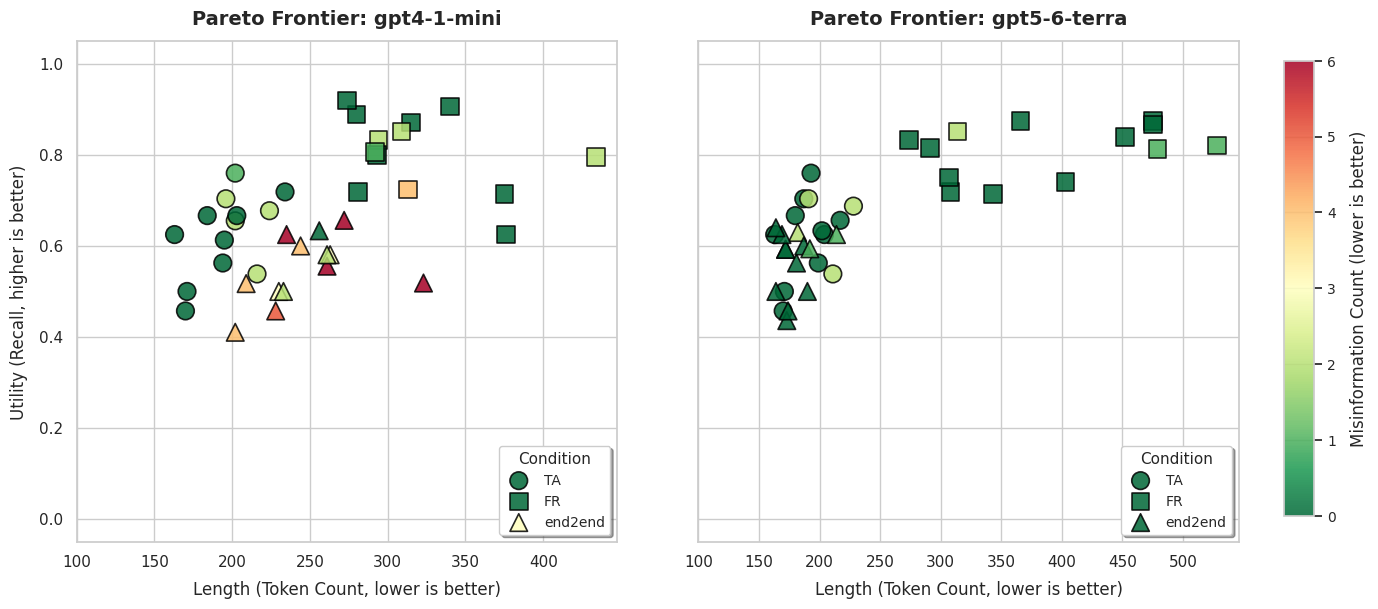

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

df_filtered = df_all[df_all["condition"].isin(["TA", "FR", "end2end"])].copy()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), sharey=True)

models = ["gpt4-1-mini", "gpt5-6-terra"]
markers = {"TA": "o", "FR": "s", "end2end": "^"}
cmap = "RdYlGn_r"

for ax, model in zip(axes, models):
    df_m = df_filtered[df_filtered["model"] == model].copy()
    sc_objects = {}
    for cond, marker in markers.items():
        df_c = df_m[df_m["condition"] == cond]
        if len(df_c) == 0: continue
        sc = ax.scatter(
            df_c["token_count"],
            df_c["recall"],
            c=df_c["misinformation_count"],
            cmap=cmap,
            marker=marker,
            s=160,
            edgecolors="black",
            linewidths=1.2,
            alpha=0.85,
            vmin=0,
            vmax=6,
            label=cond
        )
        sc_objects[cond] = sc
        
    ax.set_title(f"Pareto Frontier: {model}", fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Length (Token Count, lower is better)", fontsize=12, labelpad=8)
    if ax == axes[0]:
        ax.set_ylabel("Utility (Recall, higher is better)", fontsize=12, labelpad=8)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(left=100)
    ax.legend(title="Condition", loc="lower right", frameon=True, shadow=True, fontsize=10, title_fontsize=11)

cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sc, cax=cbar_ax)
cbar.set_label("Misinformation Count (lower is better)", fontsize=12, labelpad=10)
cbar.ax.tick_params(labelsize=10)

plt.subplots_adjust(right=0.90, wspace=0.15)
plt.savefig("pareto_frontier_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
